# Benchmark definitivo de dominio mixto: siete ZIP, partición fija y cinco semillas

## Propósito

Este notebook integra conjuntamente los siete dominios de calidad y orientación disponibles en RRUFF y evalúa la CNN descrita en el principal paper de referencia  *Deep Convolutional Neural Networks for Raman Spectrum Recognition: A Unified Solution*, mediante una partición global por fuentes. Busca medir robustez frente a una distribución espectral heterogénea y no solamente desempeño en condiciones ideales.

## Pregunta experimental

¿Qué capacidad de generalización muestra la CNN hacia fuentes minerales no vistas cuando entrenamiento, validación y prueba contienen la diversidad conjunta de los siete dominios?

## Principios del protocolo

- Los siete archivos requeridos se auditan como un único conjunto experimental.
- Cada `source_id` se asigna globalmente a una sola partición, incluso si aparece en varios ZIP.
- La partición se congela antes del entrenamiento y se reutiliza en las cinco semillas.
- Validación controla la mejor época; test se utiliza solo para evaluación.
- Se informan métricas globales, por clase y por dominio.
- Se exporta un candidato de producción elegido exclusivamente por validación.

La mezcla de dominios hace el problema más representativo de variaciones de calidad y orientación, aunque no sustituye una validación externa con otros instrumentos o colecciones.

Este notebook lee los TXT directamente desde los ZIP y muestra resultados inline. No exporta archivos ni crea carpetas de resultados.

## 1. Importaciones y reproducibilidad

Se cargan las bibliotecas necesarias para manipular los espectros, construir la red neuronal, entrenarla y calcular las métricas. También se fijan las semillas de Python, NumPy y TensorFlow para reducir las variaciones no controladas entre ejecuciones. La salida de la celda registra las versiones de software y la disponibilidad de GPU, información esencial para reproducir el experimento en otro equipo.

La reproducibilidad absoluta puede depender del hardware y de algunas operaciones internas de TensorFlow; por ello, el experimento se repite con cinco semillas y se informa la media y la desviación estándar, en lugar de basarse en una única ejecución.

In [1]:
import os, re, json, random, zipfile, platform, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.interpolate import interp1d
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    log_loss, accuracy_score, top_k_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Devices:", tf.config.list_physical_devices())
print("✓ Reproducibilidad configurada")

# Modo solo pantalla: no se escriben resultados en disco.
def _mostrar_en_pantalla(obj, destino=None, *args, **kwargs):
    nombre = str(destino) if destino is not None else "salida tabular"
    print(f"\n[SOLO PANTALLA] {nombre} | dimensiones: {getattr(obj, 'shape', None)}")
    try:
        display(obj if len(obj) <= 40 else obj.head(40))
    except Exception:
        print(obj)

pd.DataFrame.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
pd.Series.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
np.save = lambda destino, datos, *a, **k: _mostrar_en_pantalla(pd.DataFrame(np.atleast_1d(datos)), destino)
plt.savefig = lambda destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
Path.write_text = lambda self, data, *a, **k: print(f"[SOLO PANTALLA] {self.name}:\n{str(data)[:4000]}") or len(str(data))

class ZipMember:
    """Referencia ligera a un TXT dentro de un ZIP, sin extracción a disco."""
    def __init__(self, archive_path, member):
        self.archive_path, self.member = Path(archive_path), member
    @property
    def name(self): return Path(self.member).name
    def read_bytes(self):
        with zipfile.ZipFile(self.archive_path) as zf: return zf.read(self.member)
    def __str__(self): return f"{self.archive_path.name}::{self.member}"
    def __repr__(self): return str(self)

def open_spectrum(member):
    import io
    return io.StringIO(member.read_bytes().decode("utf-8", errors="replace"))


Python: 3.11.15
TensorFlow: 2.21.0
NumPy: 2.4.6
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✓ Reproducibilidad configurada


## 2. Configuración del experimento

Esta celda centraliza las rutas, las semillas, el tamaño de la rejilla Raman, los criterios mínimos de inclusión, los hiperparámetros y la carpeta de resultados. Mantener estos valores reunidos permite auditar qué se ejecutó y evita cambios accidentales entre semillas.

Los nombres de variables y archivos permanecen en inglés porque forman parte del contrato computacional del notebook. Su significado metodológico se explica en español en cada sección.

In [2]:
REQUIRED_ZIP_FILENAMES = [
    "excellent_unoriented.zip",
    "excellent_oriented.zip",
    "fair_unoriented.zip",
    "fair_oriented.zip",
    "poor_unoriented.zip",
    "unrated_unoriented.zip",
    "unrated_oriented.zip",
]
ARCHIVE_SEARCH_DIRS = [Path.cwd(), Path.cwd() / "upload", Path("/content")]

NOTEBOOK_VERSION = "FIXED_SPLIT_5_SEEDS_FINAL_2026_08_10"
WORK_DIR = Path("raman_all_7_zips_mixed_fixed_split_5_seeds")
EXTRACT_ROOT = WORK_DIR / "extracted"
RESULTS_DIR = WORK_DIR / "results"

MIN_CLASS_COUNT = 5
MIN_SOURCE_GROUPS = 3
REQUIRE_RELIABLE_SOURCE_IDS = True
N_GRID_POINTS = 512
COVERAGE_FRACTION = 0.95
MAX_EPOCHS = 150
SEEDS = [42, 123, 456, 789, 2026]
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 15
LR_PATIENCE = 6
N_SPLIT_CANDIDATES = 1000

MAX_SHIFT_POINTS = 3
SHIFT_PROBABILITY = 0.70
MAX_NOISE_STD = 0.01
NOISE_PROBABILITY = 0.70


config = {
    "notebook_version": NOTEBOOK_VERSION,
    "split_seed": SEED,
    "training_seeds": SEEDS,
    "required_archives": REQUIRED_ZIP_FILENAMES,
    "archive_policy": "manifiesto exacto de siete archivos; integridad, número de textos, lecturas válidas y participación en la partición verificados",
    "evaluation_domain": "mixed domain: all seven archives",
    "split_policy": "asignación global por fuente resuelta; todos los espectros de una fuente permanecen en una sola partición en todos los archivos",
    "class_policy": "conservar etiquetas con al menos 5 espectros y 3 grupos de fuentes resueltos en el conjunto de siete archivos",
    "min_class_count": MIN_CLASS_COUNT,
    "min_source_groups": MIN_SOURCE_GROUPS,
    "n_grid_points": N_GRID_POINTS,
    "coverage_fraction": COVERAGE_FRACTION,
    "max_epochs": MAX_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "split_candidates": N_SPLIT_CANDIDATES,
    "augmentation": {
        "training_only": True,
        "max_shift_points": MAX_SHIFT_POINTS,
        "shift_probability": SHIFT_PROBABILITY,
        "max_noise_std": MAX_NOISE_STD,
        "noise_probability": NOISE_PROBABILITY,
        "edge_handling": "valor del borde más próximo; sin desplazamiento circular ni relleno con ceros",
        "renormalize_after_augmentation": True,
    },
}
(RESULTS_DIR / "config.json").write_text(json.dumps(config, indent=2))
print(f"✓ {NOTEBOOK_VERSION}: configuración de dominio mixto guardada")


[SOLO PANTALLA] config.json:
{
  "notebook_version": "FIXED_SPLIT_5_SEEDS_FINAL_2026_08_10",
  "split_seed": 42,
  "training_seeds": [
    42,
    123,
    456,
    789,
    2026
  ],
  "required_archives": [
    "excellent_unoriented.zip",
    "excellent_oriented.zip",
    "fair_unoriented.zip",
    "fair_oriented.zip",
    "poor_unoriented.zip",
    "unrated_unoriented.zip",
    "unrated_oriented.zip"
  ],
  "archive_policy": "manifiesto exacto de siete archivos; integridad, n\u00famero de textos, lecturas v\u00e1lidas y participaci\u00f3n en la partici\u00f3n verificados",
  "evaluation_domain": "mixed domain: all seven archives",
  "split_policy": "asignaci\u00f3n global por fuente resuelta; todos los espectros de una fuente permanecen en una sola partici\u00f3n en todos los archivos",
  "class_policy": "conservar etiquetas con al menos 5 espectros y 3 grupos de fuentes resueltos en el conjunto de siete archivos",
  "min_class_count": 5,
  "min_source_groups": 3,
  "n_grid_points":

## 3. Localización, verificación y extracción de los datos

Se buscan los archivos ZIP requeridos en las ubicaciones admitidas y se comprueba que sean archivos válidos. Los espectros se extraen en directorios separados y cada registro conserva la procedencia del ZIP original. Además, se calcula una huella digital del contenido para identificar duplicados exactos: una copia se conserva y las repeticiones idénticas se excluyen del análisis.

Esta etapa no modifica los archivos originales. Su objetivo es producir un inventario trazable y evitar que copias idénticas inflen artificialmente el número de observaciones.

In [3]:
import hashlib
import shutil

def slug_from_archive(path):
    slug = re.sub(r"[^a-z0-9]+", "_", path.stem.lower()).strip("_")
    return slug or "archive"

def resolve_required_archives():
    resolved = {}
    duplicate_locations = {}
    for filename in REQUIRED_ZIP_FILENAMES:
        matches = [
            (folder / filename).resolve()
            for folder in ARCHIVE_SEARCH_DIRS
            if (folder / filename).is_file()
        ]
        if matches:
            resolved[filename] = matches[0]
            if len(matches) > 1:
                duplicate_locations[filename] = [str(path) for path in matches]
    missing = [name for name in REQUIRED_ZIP_FILENAMES if name not in resolved]
    if missing:
        raise FileNotFoundError(
            "Faltan los archivos Raman requeridos: " + ", ".join(missing) +
            ". Colóquelos junto al notebook, en upload/ o en /content."
        )
    if duplicate_locations:
        print("Nota: se encontraron ubicaciones duplicadas; se utiliza la primera coincidencia:")
        print(json.dumps(duplicate_locations, indent=2))
    return resolved

resolved_archives = resolve_required_archives()
archive_specs = [
    (slug_from_archive(Path(filename)), resolved_archives[filename])
    for filename in REQUIRED_ZIP_FILENAMES
]

archive_inventory = pd.DataFrame([
    {
        "dataset_subset": subset,
        "zip_filename": path.name,
        "zip_path": str(path),
        "role": "mixed_domain_train_validation_test",
    }
    for subset, path in archive_specs
])
archive_inventory.to_csv(RESULTS_DIR / "archive_inventory.csv", index=False)
display(archive_inventory)

file_entries = []
archive_file_counts = []
for dataset_subset, zip_path in archive_specs:
    with zipfile.ZipFile(zip_path) as archive:
        members = sorted(n for n in archive.namelist() if n.lower().endswith(".txt"))
    if not members:
        raise RuntimeError(f"{zip_path.name} no contiene espectros .txt.")
    subset_files = [ZipMember(zip_path, member) for member in members]
    file_entries.extend((path, dataset_subset) for path in subset_files)
    archive_file_counts.append({"dataset_subset": dataset_subset, "zip_filename": zip_path.name, "text_files": len(subset_files)})
    print(f"{dataset_subset}: {len(subset_files)} TXT leídos directamente de {zip_path.name}")

# Los duplicados exactos se detectan sobre los bytes internos, sin extraerlos.
seen_hashes, unique_entries, duplicate_rows = {}, [], []
for path, dataset_subset in file_entries:
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest in seen_hashes:
        kept_path, kept_subset = seen_hashes[digest]
        duplicate_rows.append({"excluded_filepath": str(path), "excluded_subset": dataset_subset,
                               "kept_filepath": str(kept_path), "kept_subset": kept_subset, "sha256": digest})
    else:
        seen_hashes[digest] = (path, dataset_subset)
        unique_entries.append((path, dataset_subset))

duplicate_table = pd.DataFrame(duplicate_rows)
display(duplicate_table.head(40))
filepaths = [path for path, _ in unique_entries]
dataset_by_path = {str(path): subset for path, subset in unique_entries}
print("Archivos TXT únicos:", len(filepaths))
print("Duplicados exactos excluidos:", len(duplicate_rows))
print("✓ ZIP leídos directamente; no se crearon carpetas de extracción")



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/archive_inventory.csv | dimensiones: (7, 4)


,dataset_subset,zip_filename,zip_path,role
0,excellent_unoriented,excellent_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,mixed_domain_train_validation_test
1,excellent_oriented,excellent_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,mixed_domain_train_validation_test
2,fair_unoriented,fair_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,mixed_domain_train_validation_test
3,fair_oriented,fair_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,mixed_domain_train_validation_test
4,poor_unoriented,poor_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/poor...,mixed_domain_train_validation_test
5,unrated_unoriented,unrated_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,mixed_domain_train_validation_test
6,unrated_oriented,unrated_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,mixed_domain_train_validation_test


,dataset_subset,zip_filename,zip_path,role
0,excellent_unoriented,excellent_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,mixed_domain_train_validation_test
1,excellent_oriented,excellent_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,mixed_domain_train_validation_test
2,fair_unoriented,fair_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,mixed_domain_train_validation_test
3,fair_oriented,fair_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,mixed_domain_train_validation_test
4,poor_unoriented,poor_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/poor...,mixed_domain_train_validation_test
5,unrated_unoriented,unrated_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,mixed_domain_train_validation_test
6,unrated_oriented,unrated_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,mixed_domain_train_validation_test


excellent_unoriented: 11415 TXT leídos directamente de excellent_unoriented.zip
excellent_oriented: 7668 TXT leídos directamente de excellent_oriented.zip
fair_unoriented: 2951 TXT leídos directamente de fair_unoriented.zip
fair_oriented: 25 TXT leídos directamente de fair_oriented.zip
poor_unoriented: 1639 TXT leídos directamente de poor_unoriented.zip
unrated_unoriented: 639 TXT leídos directamente de unrated_unoriented.zip
unrated_oriented: 3778 TXT leídos directamente de unrated_oriented.zip


,excluded_filepath,excluded_subset,kept_filepath,kept_subset,sha256
0,excellent_oriented.zip::Baddeleyite__R060016-3...,excellent_oriented,excellent_oriented.zip::Baddeleyite__R060016-3...,excellent_oriented,426f0f31f6c1625b1daf383871926cba440399f61d381d...
1,excellent_oriented.zip::Calcite__R050009-3__Ra...,excellent_oriented,excellent_oriented.zip::Calcite__R050009-3__Ra...,excellent_oriented,17ad51cea7b9a9d245ed9dbcba04adea065f7285ce1283...
2,excellent_oriented.zip::Dolomite__R050241-3__R...,excellent_oriented,excellent_oriented.zip::Dolomite__R050241-3__R...,excellent_oriented,8d37941f3aa0c961cdf13ccf4f66266b22fa7d42751dd2...
3,excellent_oriented.zip::Dolomite__R050241-3__R...,excellent_oriented,excellent_oriented.zip::Dolomite__R050241-3__R...,excellent_oriented,b8339091a2a81de275fea839312b7db4882a448e7f3472...
4,excellent_oriented.zip::Forsterite__R060539-5_...,excellent_oriented,excellent_oriented.zip::Forsterite__R060539-5_...,excellent_oriented,4c4e05dcfe04d5575657a7c5d7304d84c85c06feded390...
5,excellent_oriented.zip::Talc__R050087-5__Raman...,excellent_oriented,excellent_oriented.zip::Talc__R050087-5__Raman...,excellent_oriented,e173170cf8eafa3a1fba838c5e2fd095545bb7d765c876...
6,excellent_oriented.zip::Talc__R050087-6__Raman...,excellent_oriented,excellent_oriented.zip::Talc__R050087-6__Raman...,excellent_oriented,b1d488f58d23e1bd8e24044d9cfa1e04af9683c52b3aad...
7,excellent_oriented.zip::Talc__R050087-7__Raman...,excellent_oriented,excellent_oriented.zip::Talc__R050087-7__Raman...,excellent_oriented,6da97731c820f191d32c3b37255ff6d8b9fe2bd255aeae...
8,unrated_unoriented.zip::Margarosanite__R120111...,unrated_unoriented,excellent_unoriented.zip::Margarosanite__R1201...,excellent_unoriented,82cca24642ab104d957d1125f37c3ecddf6069ebecc118...
9,unrated_unoriented.zip::Margarosanite__R120111...,unrated_unoriented,excellent_unoriented.zip::Margarosanite__R1201...,excellent_unoriented,b43350d5cb50e8aecb10e32dee0153b5f00c5151b4b315...


Archivos TXT únicos: 28099
Duplicados exactos excluidos: 16
✓ ZIP leídos directamente; no se crearon carpetas de extracción


## 4. Lectura de espectros y auditoría de identificadores RRUFF

El analizador extrae los pares numéricos de desplazamiento Raman e intensidad, ordena las coordenadas y verifica que cada espectro tenga suficientes puntos finitos, un eje no degenerado y una señal utilizable. Los archivos que no cumplen estos requisitos quedan registrados con el motivo del rechazo.

También se recupera el identificador de fuente RRUFF —por ejemplo, `R040063`— tanto del nombre del archivo como de su cabecera. Este identificador representa la muestra o fuente mineral y se utiliza como unidad de agrupación. La auditoría permite detectar identificadores ausentes, ambiguos o asociados a etiquetas incompatibles antes de construir las particiones, reduciendo así el riesgo de fuga de información.

In [4]:
NUMBER = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][-+]?\d+)?")
RRUFF_ID = re.compile(r"(?<![A-Za-z0-9])R\d{6,8}(?!\d)", re.IGNORECASE)

def mineral_from_filename(path):
    label = path.name.split("__")[0].strip()
    return label.replace("_", " ")

def unique_rruff_ids(text):
    return sorted({m.upper() for m in RRUFF_ID.findall(text)})

def load_spectrum_and_header(path):
    pairs, header_lines = [], []
    try:
        with open_spectrum(path) as handle:
            for line in handle:
                if line.lstrip().startswith("##"):
                    header_lines.append(line.strip())
                    continue
                if not line.strip():
                    continue
                values = NUMBER.findall(line)
                if len(values) >= 2:
                    try:
                        pairs.append((float(values[0]), float(values[1])))
                    except ValueError:
                        pass
        if len(pairs) < 10:
            return None, header_lines, "menos de 10 pares numéricos"
        arr = np.asarray(pairs, dtype=np.float64)
        arr = arr[np.isfinite(arr[:, 0])]
        if len(arr) < 10:
            return None, header_lines, "muy pocas coordenadas Raman finitas"
        if not np.isfinite(arr[:, 1]).all():
            return None, header_lines, "intensidades no finitas"
        frame = pd.DataFrame({"shift": arr[:, 0], "intensity": arr[:, 1]})
        frame = frame.groupby("shift", as_index=False)["intensity"].mean().sort_values("shift")
        if len(frame) < 10 or frame["shift"].iloc[-1] <= frame["shift"].iloc[0]:
            return None, header_lines, "eje Raman degenerado"
        if np.max(np.abs(frame["intensity"].to_numpy())) <= 1e-12:
            return None, header_lines, "espectro plano o prácticamente nulo"
        spectrum = (frame["shift"].to_numpy(), frame["intensity"].to_numpy())
        return spectrum, header_lines, None
    except Exception as exc:
        return None, header_lines, f"error de lectura: {type(exc).__name__}"

records, parsed = [], {}
for i, path in enumerate(filepaths):
    dataset_subset = dataset_by_path[str(path)]
    result, header_lines, reason = load_spectrum_and_header(path)
    filename_ids = unique_rruff_ids(path.name)
    header_ids = unique_rruff_ids("\n".join(header_lines))
    candidate_ids = sorted(set(filename_ids) | set(header_ids))
    conflict = bool(filename_ids and header_ids and set(filename_ids) != set(header_ids))
    resolved_source_id = candidate_ids[0] if len(candidate_ids) == 1 and not conflict else None
    if conflict:
        source_status = "filename_header_conflict"
    elif len(candidate_ids) == 0:
        source_status = "missing"
    elif len(candidate_ids) > 1:
        source_status = "multiple_candidates"
    elif filename_ids and header_ids:
        source_status = "filename_header_agree"
    elif filename_ids:
        source_status = "filename_only"
    else:
        source_status = "header_only"

    label = mineral_from_filename(path)
    record = {
        "spectrum_id": f"S{i:06d}", "filepath": str(path), "filename": path.name,
        "dataset_subset": dataset_subset, "label": label, "accepted_parse": result is not None, "rejection_reason": reason,
        "source_id_filename": "|".join(filename_ids),
        "source_id_header": "|".join(header_ids),
        "source_id": resolved_source_id,
        "source_id_status": source_status,
    }
    if result is not None:
        shift, intensity = result
        record.update(n_points=len(shift), min_shift=float(shift.min()), max_shift=float(shift.max()))
        parsed[record["spectrum_id"]] = (shift, intensity)
    records.append(record)

manifest = pd.DataFrame(records)
source_audit = manifest[[
    "spectrum_id", "filepath", "dataset_subset", "label", "source_id_filename", "source_id_header",
    "source_id", "source_id_status", "accepted_parse"
]].copy()
source_audit.to_csv(RESULTS_DIR / "source_id_audit.csv", index=False)
manifest.to_csv(RESULTS_DIR / "parsing_manifest.csv", index=False)

parse_by_archive = (manifest.groupby("dataset_subset", as_index=False)
                    .agg(unique_text_files=("spectrum_id", "size"),
                         parsed_spectra=("accepted_parse", "sum")))
parse_by_archive["parsed_spectra"] = parse_by_archive["parsed_spectra"].astype(int)
expected_subsets = set(archive_inventory["dataset_subset"])
observed_subsets = set(parse_by_archive["dataset_subset"])
if observed_subsets != expected_subsets:
    raise RuntimeError(f"Inconsistencia en el seguimiento de archivos. Faltan subconjuntos: {sorted(expected_subsets - observed_subsets)}")
zero_parsed = parse_by_archive.loc[parse_by_archive["parsed_spectra"] == 0, "dataset_subset"].tolist()
if zero_parsed:
    raise RuntimeError("Estos archivos requeridos no produjeron ningún espectro válido: " + ", ".join(zero_parsed))
parse_by_archive.to_csv(RESULTS_DIR / "parsed_spectra_by_archive.csv", index=False)
display(parse_by_archive)
print("Archivos leídos correctamente:", int(manifest["accepted_parse"].sum()))
print("Archivos rechazados durante la lectura:", int((~manifest["accepted_parse"]).sum()))
display(manifest["source_id_status"].value_counts(dropna=False).rename("count").to_frame())
display(manifest.loc[~manifest["accepted_parse"], "rejection_reason"].value_counts().rename("count").to_frame())
print("✓ Manifiesto de lectura y auditoría de identificadores de fuente guardados")



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/source_id_audit.csv | dimensiones: (28099, 9)


,spectrum_id,filepath,dataset_subset,label,source_id_filename,source_id_header,source_id,source_id_status,accepted_parse
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,excellent_unoriented,Abellaite,R250095,R250095,R250095,filename_header_agree,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,excellent_unoriented,Abellaite,R250095,R250095,R250095,filename_header_agree,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,excellent_unoriented,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,excellent_unoriented,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,excellent_unoriented,Actinolite,R040063,R040063,R040063,filename_header_agree,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,excellent_unoriented,Actinolite,R040063,R040063,R040063,filename_header_agree,True



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/parsing_manifest.csv | dimensiones: (28099, 14)


,spectrum_id,filepath,filename,dataset_subset,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/parsed_spectra_by_archive.csv | dimensiones: (7, 3)


...

,dataset_subset,unique_text_files,parsed_spectra
0,excellent_oriented,7660,7660
1,excellent_unoriented,11415,11415
2,fair_oriented,25,25
3,fair_unoriented,2951,2951
4,poor_unoriented,1639,1639
5,unrated_oriented,3772,3772
6,unrated_unoriented,637,637


Archivos leídos correctamente: 28099
Archivos rechazados durante la lectura: 0


,count
source_id_status,
filename_header_agree,26188
filename_header_conflict,1605
missing,295
header_only,9
filename_only,2


,count
rejection_reason,


✓ Manifiesto de lectura y auditoría de identificadores de fuente guardados


## 5. Definición de la rejilla Raman común y control de cobertura

Las CNN requieren vectores de igual longitud. Por ello, se determina un intervalo Raman común a partir del conjunto de referencia y se crea una rejilla uniforme. Un espectro solo se acepta si su rango medido cubre completamente ese intervalo; no se extrapolan regiones inexistentes.

El gráfico de cobertura permite comprobar visualmente los límites mínimos y máximos disponibles. La interpolación posterior coloca todos los espectros sobre las mismas coordenadas, de modo que una posición de entrada represente el mismo desplazamiento Raman en todas las observaciones.

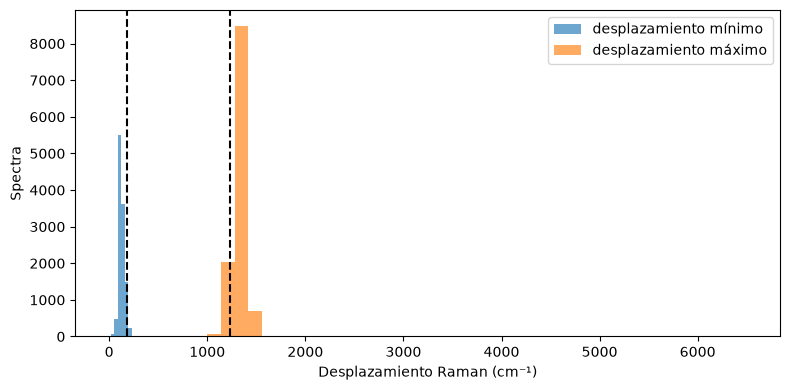

Intervalo seleccionado: 180.71–1236.15 cm⁻¹
Grid: 512 puntos; separación 2.065 cm⁻¹


,parsed,complete_coverage
dataset_subset,,
excellent_oriented,7660,6939
excellent_unoriented,11415,10299
fair_oriented,25,20
fair_unoriented,2951,2338
poor_unoriented,1639,1324
unrated_oriented,3772,3532
unrated_unoriented,637,567


Espectros con cobertura completa en el conjunto de siete dominios: 25019


In [5]:
ok = manifest[manifest["accepted_parse"]].copy()
ok_reference = ok[ok["dataset_subset"] == "excellent_unoriented"].copy()
if ok_reference.empty:
    raise RuntimeError("No se pudo leer correctamente ningún espectro excellent-unoriented.")
LOWER_LIMIT = float(np.quantile(ok_reference["min_shift"], COVERAGE_FRACTION))
UPPER_LIMIT = float(np.quantile(ok_reference["max_shift"], 1 - COVERAGE_FRACTION))
if LOWER_LIMIT >= UPPER_LIMIT:
    raise RuntimeError("No se encontró un intervalo Raman común válido. Revise el gráfico de cobertura y los archivos de datos.")
target_grid = np.linspace(LOWER_LIMIT, UPPER_LIMIT, N_GRID_POINTS, dtype=np.float32)

coverage_ok = (ok["min_shift"] <= LOWER_LIMIT) & (ok["max_shift"] >= UPPER_LIMIT)
coverage_ids = set(ok.loc[coverage_ok, "spectrum_id"])
manifest["accepted_coverage"] = manifest["spectrum_id"].isin(coverage_ids)
mask = manifest["accepted_parse"] & ~manifest["accepted_coverage"]
manifest.loc[mask, "rejection_reason"] = "cobertura insuficiente del intervalo común"

plt.figure(figsize=(8, 4))
plt.hist(ok_reference["min_shift"], bins=40, alpha=0.65, label="desplazamiento mínimo")
plt.hist(ok_reference["max_shift"], bins=40, alpha=0.65, label="desplazamiento máximo")
plt.axvline(LOWER_LIMIT, color="black", linestyle="--")
plt.axvline(UPPER_LIMIT, color="black", linestyle="--")
plt.xlabel("Desplazamiento Raman (cm⁻¹)"); plt.ylabel("Spectra"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Intervalo seleccionado: {LOWER_LIMIT:.2f}–{UPPER_LIMIT:.2f} cm⁻¹")
print(f"Grid: {N_GRID_POINTS} puntos; separación {target_grid[1]-target_grid[0]:.3f} cm⁻¹")
display(manifest[manifest["accepted_parse"]].groupby("dataset_subset")["accepted_coverage"].agg(parsed="size", complete_coverage="sum"))
print("Espectros con cobertura completa en el conjunto de siete dominios:", len(coverage_ids))


## 6. Armonización, normalización y selección de clases auditables

Cada espectro aceptado se interpola linealmente sobre la rejilla común y se normaliza dividiendo sus intensidades por el máximo valor absoluto. Esta normalización conserva la forma relativa del espectro y reduce las diferencias de escala debidas a la adquisición. Se rechazan divisores nulos o no finitos.

Después se excluyen fuentes sin identificador inequívoco y se ponen en cuarentena los identificadores asociados a más de una etiqueta mineral. Solo se retienen clases con soporte suficiente en número de espectros y en fuentes independientes para construir entrenamiento, validación y prueba por grupos. Los CSV exportados documentan qué se incluyó, qué se excluyó y por qué.

In [6]:
X_list, labels, metadata_rows = [], [], []
for row in manifest[manifest["accepted_coverage"]].itertuples():
    shift, intensity = parsed[row.spectrum_id]
    interpolated = np.interp(target_grid, shift, intensity).astype(np.float32)
    scale = float(np.max(np.abs(interpolated)))
    if not np.isfinite(scale) or scale <= 1e-12:
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "accepted_coverage"] = False
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "rejection_reason"] = "divisor de normalización no válido"
        continue
    normalized = (interpolated / scale).astype(np.float32)
    if not np.isfinite(normalized).all():
        raise AssertionError(f"Valores normalizados no finitos en {row.filepath}")
    X_list.append(normalized); labels.append(row.label)
    metadata_rows.append({
        "spectrum_id": row.spectrum_id, "filepath": row.filepath, "filename": row.filename,
        "dataset_subset": row.dataset_subset, "label": row.label, "source_id": row.source_id, "source_id_status": row.source_id_status,
    })

X_all = np.asarray(X_list, dtype=np.float32)
metadata_all = pd.DataFrame(metadata_rows)
missing_source = metadata_all["source_id"].isna()
n_unresolved = int(missing_source.sum())
if n_unresolved:
    unresolved = metadata_all.loc[missing_source, [
        "spectrum_id", "filepath", "filename", "dataset_subset", "label", "source_id_status"
    ]].copy()
    unresolved.to_csv(RESULTS_DIR / "excluded_unresolved_source_ids.csv", index=False)
    print(f"Se ponen en cuarentena {n_unresolved} espectros utilizables sin un identificador de fuente resuelto de manera inequívoca.")
    display(unresolved.head(30))

if REQUIRE_RELIABLE_SOURCE_IDS:
    resolved_mask = (~missing_source).to_numpy()
    X_all = X_all[resolved_mask]
    metadata_all = metadata_all.loc[~missing_source].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No spectra with reliable source IDs remain. Review source_id_audit.csv and "
        "excluded_unresolved_source_ids.csv; group-aware evaluation cannot run."
    )

source_label_counts = metadata_all.groupby("source_id")["label"].nunique()
colliding_sources = source_label_counts[source_label_counts > 1]
n_conflicting_sources = int(len(colliding_sources))
n_conflicting_spectra = 0
if n_conflicting_sources:
    conflict_mask = metadata_all["source_id"].isin(colliding_sources.index)
    collision_rows = metadata_all.loc[conflict_mask].copy()
    n_conflicting_spectra = int(conflict_mask.sum())
    collision_rows.to_csv(RESULTS_DIR / "source_label_conflicts.csv", index=False)
    conflict_summary = (collision_rows.groupby("source_id")
                        .agg(n_labels=("label", "nunique"),
                             labels=("label", lambda s: " | ".join(sorted(set(s)))),
                             n_spectra=("spectrum_id", "size"))
                        .reset_index().sort_values(["n_labels", "n_spectra"], ascending=False))
    conflict_summary.to_csv(RESULTS_DIR / "source_label_conflict_summary.csv", index=False)
    print(f"Se ponen en cuarentena {n_conflicting_spectra} espectros procedentes de {n_conflicting_sources} identificadores de fuente asociados a varias etiquetas.")
    display(conflict_summary.head(30))
    clean_mask = (~conflict_mask).to_numpy()
    X_all = X_all[clean_mask]
    metadata_all = metadata_all.loc[~conflict_mask].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No quedan grupos de fuentes inequívocos después de aislar los conflictos entre etiquetas. "
        "Revise source_label_conflict_summary.csv; no es posible realizar una evaluación agrupada por fuentes."
    )

joint_clean = metadata_all.copy()
class_spectrum_counts = joint_clean["label"].value_counts()
class_source_counts = joint_clean.groupby("label")["source_id"].nunique()
class_domain_counts = joint_clean.groupby("label")["dataset_subset"].nunique()
class_audit = pd.concat([
    class_spectrum_counts.rename("usable_spectra"),
    class_source_counts.rename("distinct_sources"),
    class_domain_counts.rename("domains_present"),
], axis=1).fillna(0)
class_audit["retained"] = (
    (class_audit["usable_spectra"] >= MIN_CLASS_COUNT) &
    (class_audit["distinct_sources"] >= MIN_SOURCE_GROUPS)
)
class_audit["exclusion_reason"] = np.where(
    class_audit["usable_spectra"] < MIN_CLASS_COUNT, "too_few_spectra",
    np.where(class_audit["distinct_sources"] < MIN_SOURCE_GROUPS, "fewer_than_3_sources", "")
)
class_audit.to_csv(RESULTS_DIR / "joint_class_source_domain_audit.csv")

valid_classes = set(class_audit.index[class_audit["retained"]])
if not valid_classes:
    raise RuntimeError(
        "Ninguna clase mineral conserva al menos tres grupos de fuentes inequívocos después de la auditoría. "
        "Revise class_source_audit.csv; estos identificadores no permiten un experimento de entrenamiento, validación y prueba agrupado por fuentes."
    )
keep = metadata_all["label"].isin(valid_classes).to_numpy()
X = X_all[keep]
metadata = metadata_all.loc[keep].reset_index(drop=True)

encoder = LabelEncoder()
y = encoder.fit_transform(metadata["label"]).astype(np.int32)
class_names = encoder.classes_
n_classes = len(class_names)
X_cnn = X[..., np.newaxis].astype(np.float32)

assert len(X_cnn) == len(y) == len(metadata)
assert X_cnn.shape == (len(X), N_GRID_POINTS, 1)
assert X_cnn.dtype == np.float32 and np.isfinite(X_cnn).all()
assert metadata["source_id"].notna().all()
assert metadata.groupby("source_id")["label"].nunique().max() == 1
assert metadata.groupby("label")["source_id"].nunique().min() >= MIN_SOURCE_GROUPS

manifest.to_csv(RESULTS_DIR / "final_manifest.csv", index=False)
pd.DataFrame({"class_index": np.arange(n_classes), "label": class_names}).to_csv(
    RESULTS_DIR / "label_mapping.csv", index=False
)

display(metadata.groupby("dataset_subset").agg(spectra=("spectrum_id", "size"), sources=("source_id", "nunique")))
print("Espectros utilizables tras filtrar clases y fuentes:", len(X))
print("Espectros utilizables excluidos por identificador de fuente no resuelto:", n_unresolved)
print("Espectros excluidos por conflicto entre fuente y etiqueta:", n_conflicting_spectra)
print("Identificadores de fuente conflictivos puestos en cuarentena:", n_conflicting_sources)
print("Clases conservadas:", n_classes)
print("Fuentes distintas conservadas:", metadata["source_id"].nunique())
print("Clases excluidas:", int((~class_audit["retained"]).sum()))
print("✓ Datos de los siete dominios armonizados y grupos de fuente globalmente fiables establecidos")



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/excluded_unresolved_source_ids.csv | dimensiones: (1678, 6)


,spectrum_id,filepath,filename,dataset_subset,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,excellent_unoriented,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict


Se ponen en cuarentena 1678 espectros utilizables sin un identificador de fuente resuelto de manera inequívoca.


,spectrum_id,filepath,filename,dataset_subset,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,excellent_unoriented,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/source_label_conflicts.csv | dimensiones: (27, 7)


...

,spectrum_id,filepath,filename,dataset_subset,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift,accepted_coverage
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/label_mapping.csv | dimensiones: (255, 2)


,class_index,label
0,0,Actinolite
1,1,Adamite
2,2,Aegirine
3,3,Agardite-(Y)
4,4,Albite
5,5,Alluaudite
6,6,Almandine
7,7,Alum-(K)
8,8,Andalusite
9,9,Andradite


,spectra,sources
dataset_subset,,
excellent_oriented,4802,307
excellent_unoriented,3594,963
fair_oriented,10,2
fair_unoriented,571,219
poor_unoriented,318,147
unrated_oriented,2577,346
unrated_unoriented,40,24


Espectros utilizables tras filtrar clases y fuentes: 11912
Espectros utilizables excluidos por identificador de fuente no resuelto: 1678
Espectros excluidos por conflicto entre fuente y etiqueta: 27
Identificadores de fuente conflictivos puestos en cuarentena: 2
Clases conservadas: 255
Fuentes distintas conservadas: 1113
Clases excluidas: 1999
✓ Datos de los siete dominios armonizados y grupos de fuente globalmente fiables establecidos


## 7. Inspección descriptiva de los datos procesados

Los gráficos resumen el desbalance entre clases y muestran ejemplos de espectros ya armonizados. El histograma indica cuántos espectros aporta cada mineral, mientras que las curvas permiten comprobar que la rejilla y la normalización producen señales coherentes.

Estas visualizaciones son exclusivamente descriptivas: no intervienen en la selección de la partición, de la semilla ni del modelo, y por tanto no introducen información del conjunto de prueba en el entrenamiento.

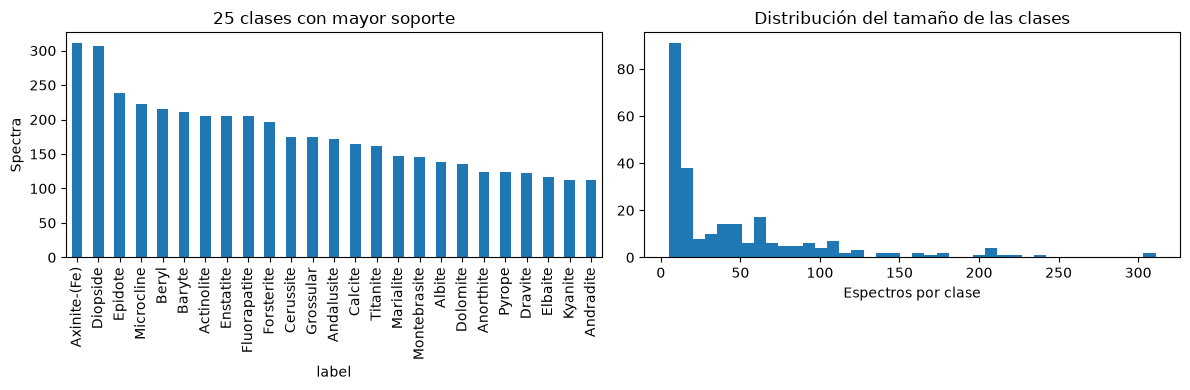

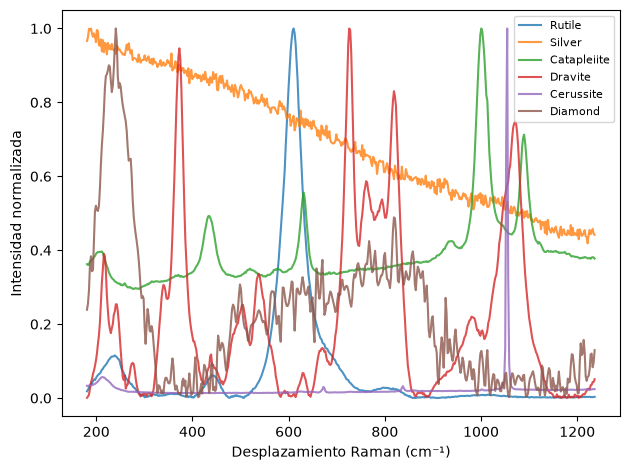

In [7]:
counts = metadata["label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.head(25).plot.bar(ax=axes[0]); axes[0].set_title("25 clases con mayor soporte"); axes[0].set_ylabel("Spectra")
axes[1].hist(counts.values, bins=40); axes[1].set_title("Distribución del tamaño de las clases"); axes[1].set_xlabel("Espectros por clase")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(SEED)
for idx in rng.choice(len(X), size=min(6, len(X)), replace=False):
    plt.plot(target_grid, X[idx], alpha=0.8, label=metadata.loc[idx, "label"])
plt.xlabel("Desplazamiento Raman (cm⁻¹)"); plt.ylabel("Intensidad normalizada")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## 8. Partición global por fuentes en los siete dominios

La búsqueda de partición reserva fuentes completas para entrenamiento, validación y prueba. Una fuente se asigna globalmente: si aparece en más de un ZIP, todos sus espectros permanecen en la misma partición. Esta restricción es más exigente que dividir archivos al azar, pero evita que el modelo sea evaluado con mediciones relacionadas con las que ya vio.

Entre las particiones candidatas se selecciona de forma determinista la de mejor cobertura y equilibrio de dominios, sin consultar el rendimiento de la CNN. Debido a las restricciones reales de fuentes y clases, puede no ser matemáticamente posible que los siete dominios aparezcan en las tres particiones; la tabla exportada deja explícita la cobertura alcanzada.

In [8]:
def candidate_global_source_split(metadata_subset, seed):
    """Reserva una fuente para validación y otra para prueba por clase; cada fuente se mantiene globalmente en una sola partición."""
    rng = np.random.default_rng(seed)
    source_partition = {}
    for label in sorted(metadata_subset["label"].unique()):
        sources = metadata_subset.loc[metadata_subset["label"] == label, "source_id"].drop_duplicates().to_numpy(dtype=object)
        if len(sources) < MIN_SOURCE_GROUPS:
            raise AssertionError(f"{label} has fewer than {MIN_SOURCE_GROUPS} grupos de fuentes globales")
        rng.shuffle(sources)
        source_partition[sources[0]] = "test"
        source_partition[sources[1]] = "validation"
        for source_id in sources[2:]:
            source_partition[source_id] = "train"
    partitions = metadata_subset["source_id"].map(source_partition)
    if partitions.isna().any():
        raise AssertionError("Al menos una fuente no fue asignada globalmente")
    return partitions

required_domains = set(metadata["dataset_subset"].unique())
if required_domains != {Path(name).stem for name in REQUIRED_ZIP_FILENAMES}:
    raise AssertionError("El conjunto mixto retenido no contiene los siete dominios requeridos")

def split_balance_score(partitions):
    table = pd.crosstab(partitions, metadata["dataset_subset"]).reindex(
        index=["train", "validation", "test"], columns=sorted(required_domains), fill_value=0
    )
    # La separación por fuentes es obligatoria; la cobertura completa de dominios es un objetivo de optimización.
    # Algunas combinaciones raras de fuente y dominio impiden completar las 21 celdas partición-dominio.
    missing_cells = int((table == 0).sum().sum())
    heldout_missing = int((table.loc[["validation", "test"]] == 0).sum().sum())
    train_missing = int((table.loc["train"] == 0).sum())
    # Se favorece una composición de dominios similar en validación y prueba, además de tamaños comparables.
    composition = table.div(table.sum(axis=1), axis=0)
    val_test_gap = float(np.square(composition.loc["validation"] - composition.loc["test"]).sum())
    heldout_size_gap = float(abs(table.loc["validation"].sum() - table.loc["test"].sum()) / len(metadata))
    # Lexicographic priorities encoded numerically: training coverage, held-out coverage, balance.
    score = 1000.0 * train_missing + 100.0 * heldout_missing + val_test_gap + heldout_size_gap
    return score, table, missing_cells, train_missing, heldout_missing

best = None
candidate_rows = []
for offset in range(N_SPLIT_CANDIDATES):
    candidate_seed = SEED + offset
    candidate = candidate_global_source_split(metadata, candidate_seed)
    score, domain_table, missing_cells, train_missing, heldout_missing = split_balance_score(candidate)
    candidate_rows.append({
        "seed": candidate_seed, "balance_score": score,
        "missing_partition_domain_cells": missing_cells,
        "missing_training_domains": train_missing,
        "missing_heldout_domain_cells": heldout_missing,
        "all_domains_in_each_partition": bool(missing_cells == 0),
    })
    if best is None or score < best[0]:
        best = (score, candidate_seed, candidate, domain_table, missing_cells)

pd.DataFrame(candidate_rows).to_csv(RESULTS_DIR / "split_candidate_search.csv", index=False)
if best is None:
    raise RuntimeError("La búsqueda de particiones candidatas no produjo ninguna partición")

best_score, selected_split_seed, partition_series, split_domain_table, missing_domain_cells = best
train_idx = metadata.index[partition_series == "train"].to_numpy(dtype=np.int64)
val_idx = metadata.index[partition_series == "validation"].to_numpy(dtype=np.int64)
test_idx = metadata.index[partition_series == "test"].to_numpy(dtype=np.int64)

partition_sources = {
    "train": set(metadata.loc[train_idx, "source_id"]),
    "validation": set(metadata.loc[val_idx, "source_id"]),
    "test": set(metadata.loc[test_idx, "source_id"]),
}
assert partition_sources["train"].isdisjoint(partition_sources["validation"])
assert partition_sources["train"].isdisjoint(partition_sources["test"])
assert partition_sources["validation"].isdisjoint(partition_sources["test"])
assert set(np.unique(y[train_idx])) == set(np.unique(y[val_idx])) == set(np.unique(y[test_idx])) == set(range(n_classes))

X_train, y_train = X_cnn[train_idx], y[train_idx]
X_val, y_val = X_cnn[val_idx], y[val_idx]
X_test, y_test = X_cnn[test_idx], y[test_idx]

split_manifest = metadata.copy()
split_manifest["class_index"] = y
split_manifest["partition"] = partition_series.to_numpy()
split_manifest.to_csv(RESULTS_DIR / "GLOBAL_GROUP_AWARE_MIXED_DOMAIN_SPLIT_MANIFEST.csv", index=False)
split_manifest.to_csv(RESULTS_DIR / "FROZEN_SPLIT_MANIFEST.csv", index=False)

source_allocation = (split_manifest.groupby(["label", "source_id", "partition"], as_index=False)
                     .agg(n_spectra=("spectrum_id", "size"),
                          n_domains=("dataset_subset", "nunique"),
                          domains=("dataset_subset", lambda s: " | ".join(sorted(set(s))))))
source_allocation.to_csv(RESULTS_DIR / "GLOBAL_SOURCE_ALLOCATION.csv", index=False)

source_domain_allocation = (split_manifest.groupby(["partition", "dataset_subset"], as_index=False)
                            .agg(sources=("source_id", "nunique"), spectra=("spectrum_id", "size")))
source_domain_allocation.to_csv(RESULTS_DIR / "ALL_7_ZIPS_PARTITION_REPORT.csv", index=False)

domain_coverage = split_domain_table.copy()
domain_coverage.index.name = "partition"
domain_coverage = domain_coverage.reset_index().melt(
    id_vars="partition", var_name="dataset_subset", value_name="spectra"
)
domain_coverage["present"] = domain_coverage["spectra"] > 0
domain_coverage.to_csv(RESULTS_DIR / "DOMAIN_COVERAGE_FEASIBILITY_REPORT.csv", index=False)

overlap_audit = pd.DataFrame([
    {"partition_a": "train", "partition_b": "validation", "source_overlap": len(partition_sources["train"] & partition_sources["validation"])},
    {"partition_a": "train", "partition_b": "test", "source_overlap": len(partition_sources["train"] & partition_sources["test"])},
    {"partition_a": "validation", "partition_b": "test", "source_overlap": len(partition_sources["validation"] & partition_sources["test"])},
])
overlap_audit.to_csv(RESULTS_DIR / "SOURCE_OVERLAP_AUDIT.csv", index=False)
assert (overlap_audit["source_overlap"] == 0).all()

np.save(RESULTS_DIR / "train_indices.npy", train_idx)
np.save(RESULTS_DIR / "validation_indices.npy", val_idx)
np.save(RESULTS_DIR / "test_indices.npy", test_idx)

display(source_domain_allocation.pivot(index="dataset_subset", columns="partition", values=["sources", "spectra"]).fillna(0).astype(int))
display(overlap_audit)
print(f"Semilla seleccionada para la partición: {selected_split_seed}; puntuación de equilibrio: {best_score:.6f}")
print(f"Entrenamiento: {len(train_idx)} | Validación: {len(val_idx)} | Prueba: {len(test_idx)}")
print(f"Cobertura de dominios: {21 - missing_domain_cells}/21 combinaciones partición-dominio representadas")
if missing_domain_cells:
    missing = domain_coverage.loc[~domain_coverage["present"], ["partition", "dataset_subset"]]
    print("ADVERTENCIA: no es posible lograr cobertura completa de dominios en cada partición bajo la separación global por fuentes seleccionada.")
    display(missing.reset_index(drop=True))
print("✓ Partición mixta independiente por fuentes creada; los siete ZIP fueron auditados conjuntamente")



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/split_candidate_search.csv | dimensiones: (1000, 6)


,seed,balance_score,missing_partition_domain_cells,missing_training_domains,missing_heldout_domain_cells,all_domains_in_each_partition
0,42,100.020789,1,0,1,False
1,43,200.029789,2,0,2,False
2,44,200.017380,2,0,2,False
3,45,200.014306,2,0,2,False
4,46,200.026081,2,0,2,False
5,47,200.007210,2,0,2,False
6,48,200.013914,2,0,2,False
7,49,200.018853,2,0,2,False
8,50,200.006334,2,0,2,False
9,51,100.019808,1,0,1,False



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/GLOBAL_GROUP_AWARE_MIXED_DOMAIN_SPLIT_MANIFEST.csv | dimensiones: (11912, 9)


,spectrum_id,filepath,filename,dataset_subset,label,source_id,source_id_status,class_index,partition
0,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
1,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
2,S000010,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
3,S000011,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
4,S000012,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
5,S000013,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
6,S000014,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
7,S000015,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
8,S000016,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
9,S000017,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/FROZEN_SPLIT_MANIFEST.csv | dimensiones: (11912, 9)


...

sources                  spectra                 
partition               test train validation    test train validation
dataset_subset                                                        
excellent_oriented        58   190         59     956  2892        954
excellent_unoriented     222   534        207     804  2019        771
fair_oriented              1     1          0       2     8          0
fair_unoriented           53   108         58     129   290        152
poor_unoriented           39    61         47      84   119        115
unrated_oriented          62   221         63     505  1587        485
unrated_unoriented         6     9          9       8    16         16

,partition_a,partition_b,source_overlap
0,train,validation,0
1,train,test,0
2,validation,test,0


Semilla seleccionada para la partición: 224; puntuación de equilibrio: 100.000933
Entrenamiento: 6931 | Validación: 2493 | Prueba: 2488
Cobertura de dominios: 20/21 combinaciones partición-dominio representadas
ADVERTENCIA: no es posible lograr cobertura completa de dominios en cada partición bajo la separación global por fuentes seleccionada.


,partition,dataset_subset
0,validation,fair_oriented


✓ Partición mixta independiente por fuentes creada; los siete ZIP fueron auditados conjuntamente


## 9. Pesos de clase calculados exclusivamente con entrenamiento

El número de espectros por mineral es desigual. Para evitar que las clases abundantes dominen la función de pérdida, se asigna a cada clase un peso inversamente relacionado con su frecuencia. Los pesos se calculan únicamente con las etiquetas originales del conjunto de entrenamiento.

No se utilizan datos de validación ni de prueba para este cálculo. Así se conserva la independencia de las particiones y se evita adaptar indirectamente el entrenamiento a la composición del test.

In [9]:
weights = compute_class_weight(class_weight="balanced", classes=np.arange(n_classes), y=y_train)
class_weight_dict = {int(i): float(w) for i, w in enumerate(weights)}
(RESULTS_DIR / "class_weights.json").write_text(json.dumps(class_weight_dict, indent=2))
print("Rango de pesos:", f"{weights.min():.3f}–{weights.max():.3f}")
print("✓ Pesos de clase calculados únicamente con entrenamiento")


[SOLO PANTALLA] class_weights.json:
{
  "0": 0.21070071439428484,
  "1": 0.9707282913165266,
  "2": 0.5662581699346405,
  "3": 3.397549019607843,
  "4": 0.2564187939326674,
  "5": 2.4709447415329766,
  "6": 0.31605107159142726,
  "7": 6.795098039215686,
  "8": 0.23431372549019608,
  "9": 0.3088680926916221,
  "10": 0.9060130718954248,
  "11": 13.590196078431372,
  "12": 0.23034230641409106,
  "13": 0.8493872549019608,
  "14": 6.795098039215686,
  "15": 13.590196078431372,
  "16": 0.7550108932461873,
  "17": 4.530065359477124,
  "18": 0.9060130718954248,
  "19": 0.13130624230368476,
  "20": 6.795098039215686,
  "21": 6.795098039215686,
  "22": 0.7550108932461873,
  "23": 0.46862745098039216,
  "24": 2.7180392156862747,
  "25": 6.795098039215686,
  "26": 6.795098039215686,
  "27": 0.1401051142106327,
  "28": 3.397549019607843,
  "29": 1.6987745098039215,
  "30": 13.590196078431372,
  "31": 6.795098039215686,
  "32": 0.9707282913165266,
  "33": 0.6177361853832442,
  "34": 0.71527347781217

## 10. Canal de entrenamiento determinista para cada semilla

Se construye un `tf.data.Dataset` independiente para cada ejecución. Solo durante el entrenamiento se aplica aumento de datos: un pequeño desplazamiento horizontal con relleno mediante el valor del borde y ruido gaussiano. Validación y prueba permanecen inmutables y siempre contienen los espectros normalizados originales.

Cada semilla controla la inicialización de pesos, el orden de los lotes y las transformaciones aleatorias. Repetir el mismo protocolo con cinco semillas permite estimar la sensibilidad del resultado a la aleatoriedad del entrenamiento.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE
X_val_reference = X_val.copy()
X_test_reference = X_test.copy()

def shift_with_edge_values(spectrum, shift):
    n = tf.shape(spectrum)[0]
    source_positions = tf.clip_by_value(tf.range(n) - shift, 0, n - 1)
    return tf.gather(spectrum, source_positions, axis=0)

def augment_training_spectrum(spectrum, label):
    spectrum = tf.cast(spectrum, tf.float32)
    apply_shift = tf.random.uniform(()) < SHIFT_PROBABILITY
    shift = tf.random.uniform((), -MAX_SHIFT_POINTS, MAX_SHIFT_POINTS + 1, dtype=tf.int32)
    spectrum = tf.cond(apply_shift, lambda: shift_with_edge_values(spectrum, shift), lambda: spectrum)
    apply_noise = tf.random.uniform(()) < NOISE_PROBABILITY
    noise_std = tf.random.uniform((), 0.0, MAX_NOISE_STD)
    spectrum = tf.cond(
        apply_noise,
        lambda: spectrum + tf.random.normal(tf.shape(spectrum), stddev=noise_std),
        lambda: spectrum,
    )
    scale = tf.maximum(tf.reduce_max(tf.abs(spectrum)), tf.constant(1e-7, tf.float32))
    spectrum = tf.ensure_shape(spectrum / scale, (N_GRID_POINTS, 1))
    return spectrum, label

def make_train_dataset(run_seed):
    # Se recrea en cada ejecución: mismas muestras y partición, con mezcla y aumento específicos de cada semilla.
    tf.keras.utils.set_random_seed(run_seed)
    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = (
        tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .shuffle(len(X_train), seed=run_seed, reshuffle_each_iteration=True)
        .map(augment_training_spectrum, num_parallel_calls=AUTOTUNE, deterministic=True)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )
    return dataset.with_options(options)

assert np.array_equal(X_val, X_val_reference)
assert np.array_equal(X_test, X_test_reference)
print("✓ Canal de entrenamiento por semilla preparado; validación y prueba permanecen inmutables")


✓ Canal de entrenamiento por semilla preparado; validación y prueba permanecen inmutables


## 11. Arquitectura CNN 1D K21/K11/K5

La entrada es un espectro normalizado de longitud fija. Tres bloques convolucionales detectan patrones Raman locales con 16 filtros de kernel 21, 32 filtros de kernel 11 y 64 filtros de kernel 5. La normalización por lotes estabiliza las activaciones y las operaciones de reducción condensan la información espectral.

La representación final alimenta una capa densa de 2048 unidades, regularizada con dropout, y una salida `softmax` cuyo número de nodos coincide dinámicamente con las clases retenidas. El valor de cada nodo es la probabilidad estimada de un mineral.

In [11]:
def build_model(input_shape, n_classes):
    """CNN transcrita a partir de la arquitectura de referencia suministrada."""
    inputs = tf.keras.Input(shape=input_shape, name="spectrum")
    x = inputs
    for block_number, (filters, kernel_size) in enumerate([(16, 21), (32, 11), (64, 5)], start=1):
        x = tf.keras.layers.Conv1D(
            filters,
            kernel_size,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"conv_{block_number}_{filters}f_k{kernel_size}",
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f"conv_{block_number}_bn")(x)
        x = tf.keras.layers.LeakyReLU(negative_slope=0.1, name=f"conv_{block_number}_leaky_relu")(x)
        x = tf.keras.layers.MaxPooling1D(pool_size=2, strides=2, name=f"conv_{block_number}_pool")(x)

    # El bloque «Concat» de la figura se representa aplanando todos los mapas de características finales.
    x = tf.keras.layers.Flatten(name="concat_flattened_feature_maps")(x)
    x = tf.keras.layers.Dense(2048, use_bias=False, name="dense_2048")(x)
    x = tf.keras.layers.BatchNormalization(name="dense_2048_bn")(x)
    x = tf.keras.layers.Activation("tanh", name="dense_2048_tanh")(x)

    # La figura sitúa Pooling(2,2) después de Dense(2048). Se reorganizan y agrupan características adyacentes
    # dense activations so that this unusual but explicit step is implemented faithfully.
    x = tf.keras.layers.Reshape((2048, 1), name="dense_features_as_sequence")(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2, strides=2, name="dense_feature_pool")(x)
    x = tf.keras.layers.Flatten(name="pooled_dense_features")(x)
    x = tf.keras.layers.Dropout(0.5, name="dropout_50pct")(x)

    logits = tf.keras.layers.Dense(n_classes, use_bias=False, name="class_logits")(x)
    logits = tf.keras.layers.BatchNormalization(name="class_logits_bn")(logits)
    outputs = tf.keras.layers.Activation("softmax", name="class_probabilities")(logits)
    return tf.keras.Model(inputs, outputs, name="pictured_raman_cnn_16_32_64")

_probe_model = build_model((N_GRID_POINTS, 1), n_classes)
parameter_report = {
    "model_name": _probe_model.name,
    "trainable_parameters": int(np.sum([np.prod(v.shape) for v in _probe_model.trainable_weights])),
    "total_parameters": int(_probe_model.count_params()),
    "architecture": "Conv1D 16/k21, 32/k11, 64/k5; Dense 2048; pooled dense features; dropout 0.5",
}
(RESULTS_DIR / "model_parameter_report.json").write_text(json.dumps(parameter_report, indent=2))
print("Número total de parámetros:", f"{parameter_report['total_parameters']:,}")
del _probe_model


[SOLO PANTALLA] model_parameter_report.json:
{
  "model_name": "pictured_raman_cnn_16_32_64",
  "trainable_parameters": 8670766,
  "total_parameters": 8675596,
  "architecture": "Conv1D 16/k21, 32/k11, 64/k5; Dense 2048; pooled dense features; dropout 0.5"
}
Número total de parámetros: 8,675,596


## 12. Entrenamiento de cinco modelos nuevos sobre una partición congelada

Para cada semilla se crea y compila una red desde cero. La partición de datos, el preprocesamiento y los hiperparámetros permanecen constantes. `EarlyStopping` detiene el entrenamiento cuando la pérdida de validación deja de mejorar y restaura los pesos de la mejor época; `ReduceLROnPlateau` reduce la tasa de aprendizaje cuando el progreso se estanca.

Al finalizar cada ejecución se evalúa una sola vez el conjunto de prueba congelado y se guardan el checkpoint, el historial, las probabilidades y las métricas. El test no decide cuándo detener el entrenamiento ni qué pesos conservar.

In [12]:
def compile_fresh_model(run_seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(run_seed)
    model = build_model((N_GRID_POINTS, 1), n_classes)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, n_classes), name="top_5_accuracy"),
        ],
    )
    return model

def calculate_metrics(y_true, probabilities):
    predicted = probabilities.argmax(axis=1)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, predicted, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, predicted, average="weighted", zero_division=0
    )

    # Métricas probabilísticas one-vs-rest solo para clases evaluables.
    per_class_auc, per_class_ap, per_class_support = [], [], []
    for class_index in range(n_classes):
        binary_truth = (y_true == class_index).astype(np.uint8)
        support = int(binary_truth.sum())
        if support > 0 and support < len(binary_truth):
            per_class_auc.append(roc_auc_score(binary_truth, probabilities[:, class_index]))
            per_class_ap.append(average_precision_score(binary_truth, probabilities[:, class_index]))
            per_class_support.append(support)
    auc_values = np.asarray(per_class_auc, dtype=float)
    ap_values = np.asarray(per_class_ap, dtype=float)
    support_values = np.asarray(per_class_support, dtype=float)

    one_hot = np.eye(n_classes, dtype=np.float32)[np.asarray(y_true, dtype=int)]
    multiclass_brier = float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)))

    confidence = probabilities.max(axis=1)
    correct = (predicted == y_true).astype(float)
    bin_edges = np.linspace(0.0, 1.0, 11)
    bin_ids = np.clip(np.digitize(confidence, bin_edges[1:-1], right=True), 0, 9)
    ece = 0.0
    for bin_index in range(10):
        mask = bin_ids == bin_index
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())

    return {
        "cross_entropy": float(log_loss(y_true, probabilities, labels=np.arange(n_classes))),
        "top_1_accuracy": float(accuracy_score(y_true, predicted)),
        "top_3_accuracy": float(top_k_accuracy_score(y_true, probabilities, k=min(3, n_classes), labels=np.arange(n_classes))),
        "top_5_accuracy": float(top_k_accuracy_score(y_true, probabilities, k=min(5, n_classes), labels=np.arange(n_classes))),
        "macro_precision": float(macro_p), "macro_recall": float(macro_r), "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p), "weighted_recall": float(weighted_r), "weighted_f1": float(weighted_f1),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, predicted)),
        "matthews_correlation_coefficient": float(matthews_corrcoef(y_true, predicted)),
        "macro_auroc_ovr": float(auc_values.mean()) if len(auc_values) else np.nan,
        "weighted_auroc_ovr": float(np.average(auc_values, weights=support_values)) if len(auc_values) else np.nan,
        "macro_auprc_ovr": float(ap_values.mean()) if len(ap_values) else np.nan,
        "weighted_auprc_ovr": float(np.average(ap_values, weights=support_values)) if len(ap_values) else np.nan,
        "multiclass_brier_score": multiclass_brier,
        "expected_calibration_error": float(ece),
        "ovr_evaluable_classes": int(len(auc_values)),
    }

seed_rows, history_frames, seed_probabilities, seed_models = [], [], {}, {}
total_start = time.time()

for run_number, run_seed in enumerate(SEEDS, start=1):
    print(f"\n===== Semilla {run_number}/{len(SEEDS)}: {run_seed} =====")
    run_dir = RESULTS_DIR / f"seed_{run_seed}"
    model = compile_fresh_model(run_seed)
    train_dataset = make_train_dataset(run_seed)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True, mode="min", verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=LR_PATIENCE,
            min_lr=1e-6, mode="min", verbose=1,
        ),
    ]
    run_start = time.time()
    history = model.fit(
        train_dataset, validation_data=(X_val, y_val), epochs=MAX_EPOCHS,
        class_weight=class_weight_dict, callbacks=callbacks, verbose=1,
    )
    run_minutes = (time.time() - run_start) / 60.0
    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
    history_df.insert(0, "seed", run_seed)
    history_frames.append(history_df)
    best_epoch = int(history_df.loc[history_df["val_loss"].idxmin(), "epoch"])

    # Cada modelo entrenado de forma independiente se evalúa sobre el mismo test congelado.
    test_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    assert test_prob.shape == (len(test_idx), n_classes)
    assert np.allclose(test_prob.sum(axis=1), 1.0, atol=1e-5)
    seed_probabilities[run_seed] = test_prob
    seed_models[run_seed] = model
    row = {"seed": run_seed, "best_epoch": best_epoch, "epochs_run": len(history_df),
           "training_minutes": run_minutes, **calculate_metrics(y_test, test_prob)}
    seed_rows.append(row)
    (run_dir / "test_metrics.json").write_text(json.dumps(row, indent=2), encoding="utf-8")
    print(f"Semilla {run_seed}: exactitud={row['top_1_accuracy']:.4f}, macro F1={row['macro_f1']:.4f}")

total_training_minutes = (time.time() - total_start) / 60.0
seed_metrics = pd.DataFrame(seed_rows)
all_histories = pd.concat(history_frames, ignore_index=True)
seed_metrics.to_csv(RESULTS_DIR / "SEED_RUN_METRICS.csv", index=False)
all_histories.to_csv(RESULTS_DIR / "SEED_TRAINING_HISTORY.csv", index=False)
display(seed_metrics.style.format({c: "{:.4f}" for c in seed_metrics.columns if c != "seed"}))
print(f"✓ All {len(SEEDS)} ejecuciones completadas en {total_training_minutes:.1f} minutos")



===== Semilla 1/5: 42 =====
Epoch 1/150


/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.4662 - loss: 3.9364 - top_5_accuracy: 0.7585

E0000 00:00:1786591893.966497  647126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


217/217 ━━━━━━━━━━━━━━━━━━━━ 47s 161ms/step - accuracy: 0.4662 - loss: 3.9364 - top_5_accuracy: 0.7585 - val_accuracy: 0.5620 - val_loss: 2.9777 - val_top_5_accuracy: 0.8123 - learning_rate: 0.0010
Epoch 2/150
217/217 ━━━━━━━━━━━━━━━━━━━━ 37s 168ms/step - accuracy: 0.7110 - loss: 2.4786 - top_5_accuracy: 0.9369 - val_accuracy: 0.7449 - val_loss: 1.5809 - val_top_5_accuracy: 0.9025 - learning_rate: 0.0010
Epoch 3/150
217/217 ━━━━━━━━━━━━━━━━━━━━ 35s 160ms/step - accuracy: 0.7953 - loss: 1.9121 - top_5_accuracy: 0.9632 - val_accuracy: 0.8018 - val_loss: 1.1892 - val_top_5_accuracy: 0.9138 - learning_rate: 0.0010
Epoch 4/150
217/217 ━━━━━━━━━━━━━━━━━━━━ 35s 161ms/step - accuracy: 0.8487 - loss: 1.5149 - top_5_accuracy: 0.9799 - val_accuracy: 0.8039 - val_loss: 1.0623 - val_top_5_accuracy: 0.9218 - learning_rate: 0.0010
Epoch 5/150
217/217 ━━━━━━━━━━━━━━━━━━━━ 35s 160ms/step - accuracy: 0.8756 - loss: 1.2279 - top_5_accuracy: 0.9864 - val_accuracy: 0.8387 - val_loss: 0.9281 - val_top_5_acc

...

,seed,best_epoch,epochs_run,training_minutes,cross_entropy,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_precision,macro_recall,...,weighted_f1,balanced_accuracy,matthews_correlation_coefficient,macro_auroc_ovr,weighted_auroc_ovr,macro_auprc_ovr,weighted_auprc_ovr,multiclass_brier_score,expected_calibration_error,ovr_evaluable_classes
0,42,8,23,11.699869,0.824027,0.856511,0.924437,0.938907,0.758578,0.766975,...,0.848632,0.766975,0.855376,0.989018,0.992113,0.812256,0.892559,0.225183,0.064665,255
1,123,7,22,10.229691,0.845770,0.839630,0.926045,0.936495,0.747158,0.751178,...,0.831451,0.751178,0.838453,0.990245,0.991761,0.808884,0.888428,0.237973,0.064982,255
2,456,12,27,12.624890,0.808346,0.861334,0.911174,0.929662,0.757523,0.764788,...,0.852194,0.764788,0.860227,0.989917,0.990556,0.817082,0.893789,0.211575,0.051189,255
3,789,8,23,9.898581,0.842451,0.842846,0.915997,0.934486,0.754305,0.758448,...,0.834945,0.758448,0.841706,0.989981,0.991181,0.816939,0.888822,0.227026,0.044249,255
4,2026,14,29,9.355841,0.783598,0.856913,0.928457,0.943328,0.765704,0.767318,...,0.849949,0.767318,0.855809,0.990123,0.991267,0.825393,0.899020,0.209970,0.038967,255



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/SEED_TRAINING_HISTORY.csv | dimensiones: (124, 9)


,seed,epoch,accuracy,loss,top_5_accuracy,val_accuracy,val_loss,val_top_5_accuracy,learning_rate
0,42,1,0.466166,3.936364,0.758476,0.561974,2.977672,0.812274,0.00100
1,42,2,0.711008,2.478575,0.936950,0.744886,1.580889,0.902527,0.00100
2,42,3,0.795268,1.912058,0.963209,0.801845,1.189192,0.913759,0.00100
3,42,4,0.848651,1.514941,0.979945,0.803851,1.062338,0.921781,0.00100
4,42,5,0.875631,1.227862,0.986438,0.838749,0.928132,0.924990,0.00100
5,42,6,0.892223,1.016237,0.986005,0.836342,0.900789,0.934216,0.00100
6,42,7,0.903910,0.836169,0.991632,0.838749,0.920030,0.927397,0.00100
7,42,8,0.916174,0.711902,0.990333,0.849980,0.860571,0.929402,0.00100
8,42,9,0.921945,0.610811,0.991343,0.830726,0.945164,0.925391,0.00100
9,42,10,0.927139,0.559970,0.994085,0.844765,0.932226,0.922984,0.00100


,seed,best_epoch,epochs_run,training_minutes,cross_entropy,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,balanced_accuracy,matthews_correlation_coefficient,macro_auroc_ovr,weighted_auroc_ovr,macro_auprc_ovr,weighted_auprc_ovr,multiclass_brier_score,expected_calibration_error,ovr_evaluable_classes
0,42,8.0000,23.0000,11.6999,0.8240,0.8565,0.9244,0.9389,0.7586,0.7670,0.7414,0.8716,0.8565,0.8486,0.7670,0.8554,0.9890,0.9921,0.8123,0.8926,0.2252,0.0647,255.0000
1,123,7.0000,22.0000,10.2297,0.8458,0.8396,0.9260,0.9365,0.7472,0.7512,0.7227,0.8670,0.8396,0.8315,0.7512,0.8385,0.9902,0.9918,0.8089,0.8884,0.2380,0.0650,255.0000
2,456,12.0000,27.0000,12.6249,0.8083,0.8613,0.9112,0.9297,0.7575,0.7648,0.7380,0.8754,0.8613,0.8522,0.7648,0.8602,0.9899,0.9906,0.8171,0.8938,0.2116,0.0512,255.0000
3,789,8.0000,23.0000,9.8986,0.8425,0.8428,0.9160,0.9345,0.7543,0.7584,0.7309,0.8673,0.8428,0.8349,0.7584,0.8417,0.9900,0.9912,0.8169,0.8888,0.2270,0.0442,255.0000
4,2026,14.0000,29.0000,9.3558,0.7836,0.8569,0.9285,0.9433,0.7657,0.7673,0.7426,0.8774,0.8569,0.8499,0.7673,0.8558,0.9901,0.9913,0.8254,0.8990,0.2100,0.0390,255.0000


✓ All 5 ejecuciones completadas en 54.2 minutos


## 13. Agregación de métricas y curvas de validación

Se resumen las cinco ejecuciones mediante media, desviación estándar muestral, mínimo y máximo. La exactitud Top-1 mide la proporción de primeras predicciones correctas; Top-3 y Top-5 comprueban si la clase real aparece entre las primeras alternativas. El macro F1 concede el mismo peso a cada mineral y revela dificultades en clases minoritarias, mientras que el weighted F1 pondera por soporte y describe mejor el rendimiento global sobre la distribución observada.

Las curvas de validación permiten comparar convergencia y estabilidad. Una dispersión pequeña entre semillas indica que la conclusión no depende de una inicialización excepcionalmente favorable.


[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/SEED_AGGREGATE_METRICS.csv | dimensiones: (18, 5)


,metric,mean,std,min,max
0,cross_entropy,0.820838,0.025699,0.783598,0.845770
1,top_1_accuracy,0.851447,0.009577,0.839630,0.861334
2,top_3_accuracy,0.921222,0.007318,0.911174,0.928457
3,top_5_accuracy,0.936576,0.005079,0.929662,0.943328
4,macro_precision,0.756654,0.006746,0.747158,0.765704
5,macro_recall,0.761741,0.006896,0.751178,0.767318
6,macro_f1,0.735120,0.008315,0.722675,0.742566
7,weighted_precision,0.871760,0.004680,0.867047,0.877422
8,weighted_recall,0.851447,0.009577,0.839630,0.861334
9,weighted_f1,0.843434,0.009511,0.831451,0.852194


,metric,mean,std,min,max
0,cross_entropy,0.8208,0.0257,0.7836,0.8458
1,top_1_accuracy,0.8514,0.0096,0.8396,0.8613
2,top_3_accuracy,0.9212,0.0073,0.9112,0.9285
3,top_5_accuracy,0.9366,0.0051,0.9297,0.9433
4,macro_precision,0.7567,0.0067,0.7472,0.7657
5,macro_recall,0.7617,0.0069,0.7512,0.7673
6,macro_f1,0.7351,0.0083,0.7227,0.7426
7,weighted_precision,0.8718,0.0047,0.8670,0.8774
8,weighted_recall,0.8514,0.0096,0.8396,0.8613
9,weighted_f1,0.8434,0.0095,0.8315,0.8522


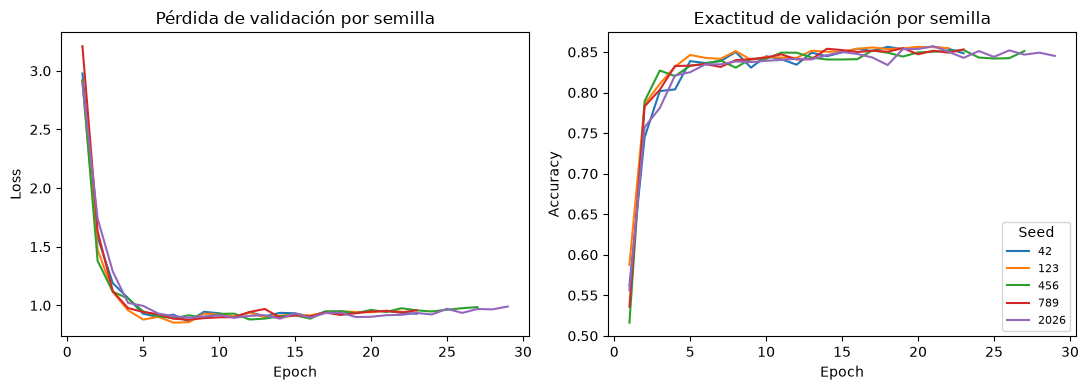

✓ Media, desviación estándar muestral, mínimo y máximo guardados


In [13]:
metric_columns = [
    "cross_entropy", "top_1_accuracy", "top_3_accuracy", "top_5_accuracy",
    "macro_precision", "macro_recall", "macro_f1",
    "weighted_precision", "weighted_recall", "weighted_f1",
    "balanced_accuracy", "matthews_correlation_coefficient",
    "macro_auroc_ovr", "weighted_auroc_ovr",
    "macro_auprc_ovr", "weighted_auprc_ovr",
    "multiclass_brier_score", "expected_calibration_error",
]
aggregate_rows = []
for metric in metric_columns:
    values = seed_metrics[metric].astype(float)
    aggregate_rows.append({
        "metric": metric,
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
        "min": float(values.min()),
        "max": float(values.max()),
    })
seed_aggregate = pd.DataFrame(aggregate_rows)
seed_aggregate.to_csv(RESULTS_DIR / "SEED_AGGREGATE_METRICS.csv", index=False)
display(seed_aggregate.style.format({c: "{:.4f}" for c in ["mean", "std", "min", "max"]}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for run_seed, frame in all_histories.groupby("seed"):
    axes[0].plot(frame["epoch"], frame["val_loss"], label=str(run_seed))
    axes[1].plot(frame["epoch"], frame["val_accuracy"], label=str(run_seed))
axes[0].set(title="Pérdida de validación por semilla", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Exactitud de validación por semilla", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend(title="Seed", fontsize=8)
fig.tight_layout()
plt.show()
print("✓ Media, desviación estándar muestral, mínimo y máximo guardados")


## Diagnóstico visual de estabilidad mediante boxplots

Estos boxplots complementan la tabla de media, desviación estándar, mínimo y máximo. Cada punto representa una de las cinco semillas; el rombo rojo representa la media. Una arquitectura candidata sólida debe combinar **rendimiento central alto** con **dispersión baja**, especialmente en `macro F1`, que concede el mismo peso a cada mineral.

Con solo cinco ejecuciones, el boxplot debe interpretarse junto con los puntos individuales: describe la estabilidad observada, pero no sustituye un intervalo de confianza ni una prueba estadística entre arquitecturas. La comparación del modelo ganador debe hacerse sobre el mismo split y usando las cinco semillas completas, nunca escogiendo únicamente la mejor ejecución.


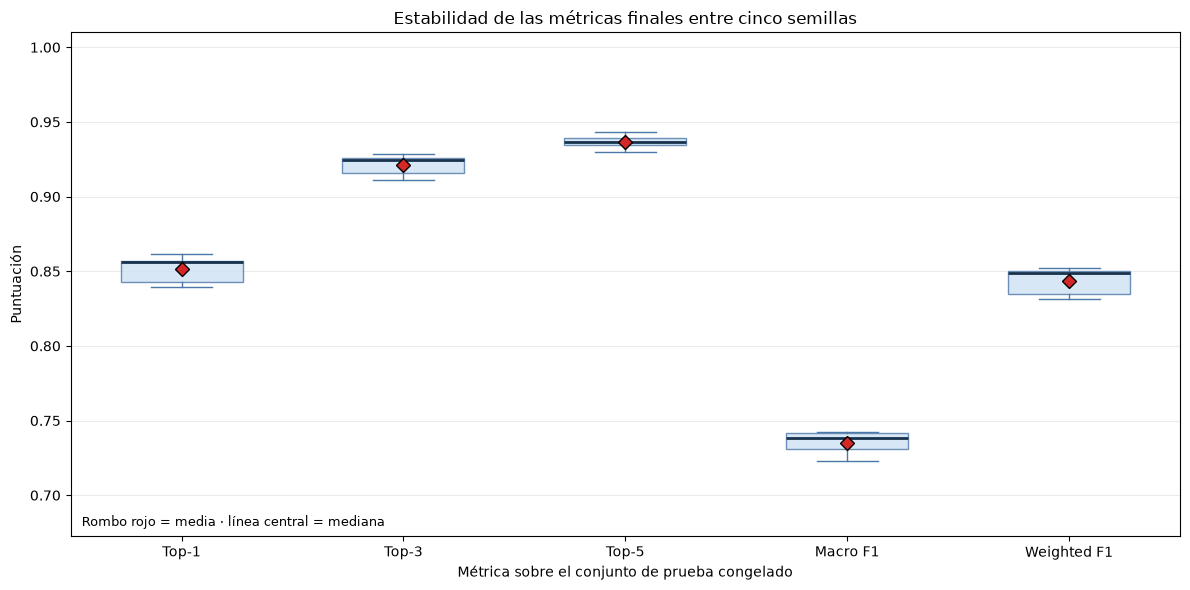

Resumen para comparar rendimiento medio y estabilidad:


,metric,mean,std,min,max,range
0,top_1_accuracy,0.8514,0.0096,0.8396,0.8613,0.0217
1,top_3_accuracy,0.9212,0.0073,0.9112,0.9285,0.0173
2,top_5_accuracy,0.9366,0.0051,0.9297,0.9433,0.0137
3,macro_f1,0.7351,0.0083,0.7227,0.7426,0.0199
4,weighted_f1,0.8434,0.0095,0.8315,0.8522,0.0207


In [14]:
# Métricas principales para comparar rendimiento y estabilidad entre semillas
stability_columns = [
    "top_1_accuracy",
    "top_3_accuracy",
    "top_5_accuracy",
    "macro_f1",
    "weighted_f1",
]

stability_labels = [
    "Top-1",
    "Top-3",
    "Top-5",
    "Macro F1",
    "Weighted F1",
]

stability_values = [
    seed_metrics[column].astype(float).to_numpy()
    for column in stability_columns
]

fig, ax = plt.subplots(figsize=(12, 6))

box = ax.boxplot(
    stability_values,
    tick_labels=stability_labels,
    widths=0.55,
    patch_artist=True,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "#d62728",
        "markeredgecolor": "black",
        "markersize": 7,
    },
    medianprops={
        "color": "#17324d",
        "linewidth": 2,
    },
    whiskerprops={"color": "#4c78a8"},
    capprops={"color": "#4c78a8"},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#4c78a8",
        "markeredgecolor": "white",
        "markersize": 5,
        "alpha": 0.8,
    },
)

for patch in box["boxes"]:
    patch.set_facecolor("#cfe2f3")
    patch.set_edgecolor("#4c78a8")
    patch.set_alpha(0.8)

lower_limit = max(
    0.0,
    min(float(values.min()) for values in stability_values) - 0.05,
)

ax.set_ylim(lower_limit, 1.01)
ax.set_title("Estabilidad de las métricas finales entre cinco semillas")
ax.set_xlabel("Métrica sobre el conjunto de prueba congelado")
ax.set_ylabel("Puntuación")
ax.grid(axis="y", alpha=0.25)

ax.text(
    0.01,
    0.02,
    "Rombo rojo = media · línea central = mediana",
    transform=ax.transAxes,
    fontsize=9,
)

fig.tight_layout()
plt.show()

# Resumen estadístico mostrado debajo del gráfico
stability_summary = pd.DataFrame({
    "metric": stability_columns,
    "mean": [values.mean() for values in stability_values],
    "std": [values.std(ddof=1) for values in stability_values],
    "min": [values.min() for values in stability_values],
    "max": [values.max() for values in stability_values],
    "range": [
        values.max() - values.min()
        for values in stability_values
    ],
})

print("Resumen para comparar rendimiento medio y estabilidad:")

display(
    stability_summary.style.format({
        "mean": "{:.4f}",
        "std": "{:.4f}",
        "min": "{:.4f}",
        "max": "{:.4f}",
        "range": "{:.4f}",
    }).background_gradient(
        subset=["std", "range"],
        cmap="YlOrRd",
    )
)

## 14. Diagnósticos de estabilidad sobre el conjunto de prueba congelado

Esta sección conserva predicciones detalladas para analizar errores, clases difíciles y variabilidad entre semillas. Las métricas del test se calculan después de finalizar cada entrenamiento y se utilizan únicamente para evaluación científica.

Los resultados de consenso o por dominio son diagnósticos complementarios: no sustituyen las métricas individuales ni se emplean para escoger retrospectivamente la mejor semilla.

In [15]:
test_meta = split_manifest.iloc[test_idx].reset_index(drop=True)
domain_seed_rows = []
for run_seed, probabilities in seed_probabilities.items():
    for domain in sorted(test_meta["dataset_subset"].unique()):
        mask = test_meta["dataset_subset"].to_numpy() == domain
        domain_seed_rows.append({
            "seed": run_seed, "domain": domain, "n_spectra": int(mask.sum()),
            "n_sources": int(test_meta.loc[mask, "source_id"].nunique()),
            **calculate_metrics(y_test[mask], probabilities[mask]),
        })
domain_seed_metrics = pd.DataFrame(domain_seed_rows)
domain_seed_metrics.to_csv(RESULTS_DIR / "SEED_TEST_METRICS_BY_ZIP_DOMAIN.csv", index=False)
domain_summary = (domain_seed_metrics.groupby("domain")[metric_columns]
                  .agg(["mean", "std"]).reset_index())
domain_summary.to_csv(RESULTS_DIR / "SEED_TEST_METRICS_BY_ZIP_DOMAIN_AGGREGATE.csv", index=False)
display(domain_seed_metrics.groupby("domain")[["top_1_accuracy", "macro_f1"]].agg(["mean", "std"]))
print("✓ Métricas de estabilidad por dominio guardadas para cada dominio representado en prueba")


/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/anaconda3


[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/SEED_TEST_METRICS_BY_ZIP_DOMAIN.csv | dimensiones: (35, 23)


/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,seed,domain,n_spectra,n_sources,cross_entropy,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_precision,macro_recall,...,weighted_f1,balanced_accuracy,matthews_correlation_coefficient,macro_auroc_ovr,weighted_auroc_ovr,macro_auprc_ovr,weighted_auprc_ovr,multiclass_brier_score,expected_calibration_error,ovr_evaluable_classes
0,42,excellent_oriented,956,58,0.493803,0.919456,0.973849,0.981172,0.752960,0.756349,...,0.919507,0.912835,0.917885,0.996804,0.995826,0.956561,0.952222,0.140787,0.063589,58
1,42,excellent_unoriented,804,222,0.837773,0.856965,0.924129,0.937811,0.817633,0.831213,...,0.839960,0.853679,0.856616,0.992187,0.992610,0.895385,0.901020,0.231744,0.060738,222
2,42,fair_oriented,2,1,0.947456,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,0.375413,0.436120,0
3,42,fair_unoriented,129,53,2.346151,0.558140,0.658915,0.728682,0.468093,0.431373,...,0.549949,0.553459,0.556604,0.962469,0.958548,0.790393,0.796415,0.598543,0.080641,53
4,42,poor_unoriented,84,39,3.766325,0.238095,0.428571,0.500000,0.169697,0.168182,...,0.229592,0.237179,0.234910,0.896279,0.886428,0.556442,0.549039,0.893202,0.139029,39
5,42,unrated_oriented,505,62,0.546883,0.916832,0.982178,0.988119,0.831824,0.808947,...,0.924850,0.926375,0.915413,0.994523,0.993372,0.958825,0.956379,0.165696,0.103077,62
6,42,unrated_unoriented,8,6,0.929822,0.750000,0.875000,0.875000,0.500000,0.500000,...,0.750000,0.666667,0.730769,1.000000,1.000000,1.000000,1.000000,0.334229,0.178068,6
7,123,excellent_oriented,956,58,0.542589,0.902720,0.970711,0.975941,0.735668,0.726526,...,0.903245,0.889368,0.900941,0.994577,0.994115,0.937929,0.944287,0.152094,0.065895,58
8,123,excellent_unoriented,804,222,0.831201,0.843284,0.929104,0.935323,0.785785,0.809710,...,0.823770,0.838889,0.842950,0.992992,0.993311,0.892177,0.897788,0.239811,0.048886,222
9,123,fair_oriented,2,1,1.014992,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,0.379230,0.450442,0



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/SEED_TEST_METRICS_BY_ZIP_DOMAIN_AGGREGATE.csv | dimensiones: (7, 37)


domain cross_entropy           top_1_accuracy            \
                                 mean       std           mean       std   
0    excellent_oriented      0.517129  0.034357       0.910879  0.010678   
1  excellent_unoriented      0.814606  0.019174       0.850995  0.005233   
2         fair_oriented      0.608111  0.375682       1.000000  0.000000   
3       fair_unoriented      2.242353  0.095334       0.555039  0.019457   
4       poor_unoriented      3.677540  0.090585       0.264286  0.037077   
5      unrated_oriented      0.568189  0.043116       0.912871  0.018993   
6    unrated_unoriented      0.824821  0.248827       0.825000  0.068465   

  top_3_accuracy           top_5_accuracy           macro_precision  ...  \
            mean       std           mean       std            mean  ...   
0       0.962762  0.011963       0.974268  0.008322        0.738626  ...   
1       0.924876  0.005393       0.938308  0.002259        0.804667  ...   
2       1.000000  0.000000       1.000000  0.000000        1.000000  ...   
3       0.683721  0.018507       0.745736  0.018507        0.457473  ...   
4       0.454762  0.028422       0.521429  0.039841        0.189667  ...   
5       0.975446  0.007871       0.980990  0.005874        0.814582  ...   
6       0.875000  0.000000       0.875000  0.000000        0.628571  ...   

  weighted_auroc_ovr           macro_auprc_ovr           weighted_auprc_ovr  \
                mean       std            mean       std               mean   
0           0.994465  0.001128        0.952782  0.009089           0.949537   
1           0.992605  0.000949        0.897162  0.004250           0.902696   
2                NaN       NaN             NaN       NaN                NaN   
3           0.960236  0.003460        0.793419  0.018107           0.800732   
4           0.880944  0.006225        0.555334  0.022892           0.539707   
5           0.991910  0.001393        0.958749  0.003848           0.955878   
6           1.000000  0.000000        1.000000  0.000000           1.000000   

            multiclass_brier_score           expected_calibration_error  \
        std                   mean       std                       mean   
0  0.004644               0.139609  0.010186                   0.047488   
1  0.003797               0.227135  0.008502                   0.052607   
2       NaN               0.233940  0.156157                   0.324851   
3  0.018936               0.592384  0.013075                   0.097751   
4  0.025884               0.881523  0.026526                   0.163318   
5  0.001600               0.166979  0.025104                   0.093365   
6  0.000000               0.231912  0.121873                   0.118511   

             
        std  
0  0.017930  
1  0.007584  
2  0.135418  
3  0.024326  
4  0.052323  
5  0.015474  
6  0.057907  

[7 rows x 37 columns]

top_1_accuracy            macro_f1          
                               mean       std      mean       std
domain                                                           
excellent_oriented         0.910879  0.010678  0.725857  0.022385
excellent_unoriented       0.850995  0.005233  0.797279  0.010959
fair_oriented              1.000000  0.000000  1.000000  0.000000
fair_unoriented            0.555039  0.019457  0.416818  0.025803
poor_unoriented            0.264286  0.037077  0.179770  0.028338
unrated_oriented           0.912871  0.018993  0.800504  0.021237
unrated_unoriented         0.825000  0.068465  0.628571  0.117369

✓ Métricas de estabilidad por dominio guardadas para cada dominio representado en prueba


## 15. Salvaguardas finales y resumen del experimento

Se verifican de nuevo las condiciones que sostienen la validez del protocolo: ausencia de fuentes compartidas entre particiones, conservación de los espectros de validación y prueba, presencia de todas las ejecuciones previstas y coherencia de los archivos exportados.

El resumen registra la configuración necesaria para interpretar y reproducir los resultados. Si alguna salvaguarda falla, el notebook se detiene en lugar de presentar como válido un experimento con posible fuga de información o ejecución incompleta.

In [16]:
split_counts = {"train": int(len(train_idx)), "validation": int(len(val_idx)), "test": int(len(test_idx))}
partition_sources = {
    "train": set(metadata.loc[train_idx, "source_id"]),
    "validation": set(metadata.loc[val_idx, "source_id"]),
    "test": set(metadata.loc[test_idx, "source_id"]),
}
overlap_audit = pd.DataFrame([
    {"partition_a": "train", "partition_b": "validation", "source_overlap": len(partition_sources["train"] & partition_sources["validation"])},
    {"partition_a": "train", "partition_b": "test", "source_overlap": len(partition_sources["train"] & partition_sources["test"])},
    {"partition_a": "validation", "partition_b": "test", "source_overlap": len(partition_sources["validation"] & partition_sources["test"])},
])
assert (overlap_audit["source_overlap"] == 0).all()
overlap_audit.to_csv(RESULTS_DIR / "SOURCE_OVERLAP_AUDIT.csv", index=False)

summary = {
    "notebook_version": "FIXED_SPLIT_5_SEEDS_FINAL_2026_08_10",
    "training_seeds": SEEDS,
    "split_is_fixed_across_seeds": True,
    "split": split_counts,
    "source_groups_cross_partitions": False,
    "checkpoint_selection": "pérdida mínima de validación calculada independientemente en cada semilla",
    "test_selection_policy": "ninguna semilla se selecciona o descarta usando el test; se informa la media ± desviación estándar muestral de todas las ejecuciones",
    "architecture": parameter_report,
    "augmentation": "desplazamiento aleatorio y ruido gaussiano solo en entrenamiento, con semilla independiente por ejecución",
    "total_training_minutes": float(total_training_minutes),
    "seed_run_metrics": seed_metrics.to_dict(orient="records"),
    "aggregate_metrics": seed_aggregate.to_dict(orient="records"),
}
(RESULTS_DIR / "experiment_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Directorio de resultados:", RESULTS_DIR.resolve())
print("✓ Experimento definitivo de estabilidad con cinco semillas completado")



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/SOURCE_OVERLAP_AUDIT.csv | dimensiones: (3, 3)


,partition_a,partition_b,source_overlap
0,train,validation,0
1,train,test,0
2,validation,test,0


[SOLO PANTALLA] experiment_summary.json:
{
  "notebook_version": "FIXED_SPLIT_5_SEEDS_FINAL_2026_08_10",
  "training_seeds": [
    42,
    123,
    456,
    789,
    2026
  ],
  "split_is_fixed_across_seeds": true,
  "split": {
    "train": 6931,
    "validation": 2493,
    "test": 2488
  },
  "source_groups_cross_partitions": false,
  "checkpoint_selection": "p\u00e9rdida m\u00ednima de validaci\u00f3n calculada independientemente en cada semilla",
  "test_selection_policy": "ninguna semilla se selecciona o descarta usando el test; se informa la media \u00b1 desviaci\u00f3n est\u00e1ndar muestral de todas las ejecuciones",
  "architecture": {
    "model_name": "pictured_raman_cnn_16_32_64",
    "trainable_parameters": 8670766,
    "total_parameters": 8675596,
    "architecture": "Conv1D 16/k21, 32/k11, 64/k5; Dense 2048; pooled dense features; dropout 0.5"
  },
  "augmentation": "desplazamiento aleatorio y ruido gaussiano solo en entrenamiento, con semilla independiente por ejecuci\u0

## Interpretación metodológica

El resultado principal debe presentarse como **media ± desviación estándar muestral de las cinco semillas**. No debe seleccionarse ni descartarse una ejecución por su rendimiento en el conjunto de prueba. La comparación entre modelos es válida porque la partición, el preprocesamiento, el aumento de datos, los callbacks y las métricas permanecen congelados dentro del protocolo.

Una diferencia entre weighted F1 y macro F1 indica rendimiento desigual entre clases: las clases con mayor soporte pueden mantener una métrica ponderada alta aunque algunos minerales minoritarios sean difíciles. Top-3 y Top-5 son útiles en un sistema de apoyo a la identificación, pero no reemplazan el análisis de Top-1 y macro F1.

Estos resultados estiman generalización hacia fuentes independientes bajo la distribución representada por el test. No demuestran desempeño universal frente a instrumentos, condiciones o minerales ausentes de RRUFF.

## 16. Diagnóstico exhaustivo del candidato seleccionado para producción

Esta sección caracteriza el checkpoint elegido mediante la **pérdida de validación**, sin usar el test para seleccionarlo. Solo después de congelar esa regla se emplea el conjunto de prueba para describir su comportamiento final.

Se generan los siguientes diagnósticos:

- **Matriz de confusión sin normalizar:** conserva el número absoluto de errores y permite detectar confusiones frecuentes.
- **Matriz normalizada por filas:** cada fila suma uno y muestra qué proporción de cada mineral real se asigna a cada predicción. Resulta más justa para comparar clases con soportes diferentes.
- **Informe por clase:** soporte, precision, recall y F1 para las 255 clases. Las clases sin ejemplos de prueba se conservan con soporte cero, pero no deben interpretarse.
- **Clases más difíciles:** se ordenan por recall entre las clases presentes en test.
- **Pares de confusión:** se excluye la diagonal y se listan los errores real → predicho más frecuentes.
- **Calibración:** compara la confianza softmax con la exactitud observada. Un modelo calibrado debería acertar aproximadamente el 80 % de las veces cuando declara una confianza de 0,80.
- **Curvas ROC y precision–recall representativas:** se muestran pocas clases con soporte suficiente para mantener la figura legible. Las métricas agregadas de AUROC y AUPRC de todas las clases evaluables ya se calculan en cada semilla.

AUROC es complementario porque el esquema one-vs-rest produce muchos negativos por clase. AUPRC es especialmente informativa ante desbalance, aunque su línea base depende de la prevalencia de cada mineral. Ninguna de estas métricas sustituye Top-1, macro F1 ni el análisis de confusiones.



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/production/final_test_predictions.csv | dimensiones: (2488, 11)


,spectrum_id,filepath,source_id,label,dataset_subset,true_class_index,predicted_class_index,predicted_label,correct,confidence,true_class_probability
0,S000024,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,165,Pargasite,False,0.644891,0.056912
1,S000025,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,165,Pargasite,False,0.467413,0.051504
2,S000026,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,165,Pargasite,False,0.852219,0.016228
3,S000027,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,165,Pargasite,False,0.876036,0.008267
4,S000028,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,165,Pargasite,False,0.834416,0.002078
5,S000029,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,165,Pargasite,False,0.658828,0.001414
6,S000056,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,excellent_unoriented,1,1,Adamite,True,0.944569,0.944569
7,S000057,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,excellent_unoriented,1,1,Adamite,True,0.912204,0.912204
8,S000058,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,excellent_unoriented,1,1,Adamite,True,0.996226,0.996226
9,S000059,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,excellent_unoriented,1,1,Adamite,True,0.994788,0.994788



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/production/final_per_class_metrics.csv | dimensiones: (255, 6)


,class_index,label,precision,recall,f1-score,support
0,0,Actinolite,1.000000,0.289474,0.448980,38.0
1,1,Adamite,1.000000,1.000000,1.000000,4.0
2,2,Aegirine,1.000000,1.000000,1.000000,4.0
3,3,Agardite-(Y),0.500000,1.000000,0.666667,2.0
4,4,Albite,0.000000,0.000000,0.000000,3.0
5,5,Alluaudite,1.000000,1.000000,1.000000,4.0
6,6,Almandine,0.500000,1.000000,0.666667,4.0
7,7,Alum-(K),0.750000,1.000000,0.857143,6.0
8,8,Andalusite,1.000000,1.000000,1.000000,28.0
9,9,Andradite,1.000000,1.000000,1.000000,12.0



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/production/final_confusion_matrix_counts.csv | dimensiones: (255, 255)


,Actinolite,Adamite,Aegirine,Agardite-(Y),Albite,Alluaudite,Almandine,Alum-(K),Andalusite,Andradite,...,Wendwilsonite,Whewellite,Willemite,Witherite,Wolfeite,Wollastonite,Wulfenite,Xenotime-(Y),Zincite,Zircon
Actinolite,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Adamite,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aegirine,0,0,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Agardite-(Y),0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albite,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alluaudite,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Almandine,0,0,0,0,0,0,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alum-(K),0,0,0,0,0,0,0,6,0,0,...,0,0,0,0,0,0,0,0,0,0
Andalusite,0,0,0,0,0,0,0,0,28,0,...,0,0,0,0,0,0,0,0,0,0
Andradite,0,0,0,0,0,0,0,0,0,12,...,0,0,0,0,0,0,0,0,0,0



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/production/final_confusion_matrix_normalized.csv | dimensiones: (255, 255)


,Actinolite,Adamite,Aegirine,Agardite-(Y),Albite,Alluaudite,Almandine,Alum-(K),Andalusite,Andradite,...,Wendwilsonite,Whewellite,Willemite,Witherite,Wolfeite,Wollastonite,Wulfenite,Xenotime-(Y),Zincite,Zircon
Actinolite,0.289474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Adamite,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aegirine,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Agardite-(Y),0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Albite,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alluaudite,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Almandine,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alum-(K),0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Andalusite,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Andradite,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


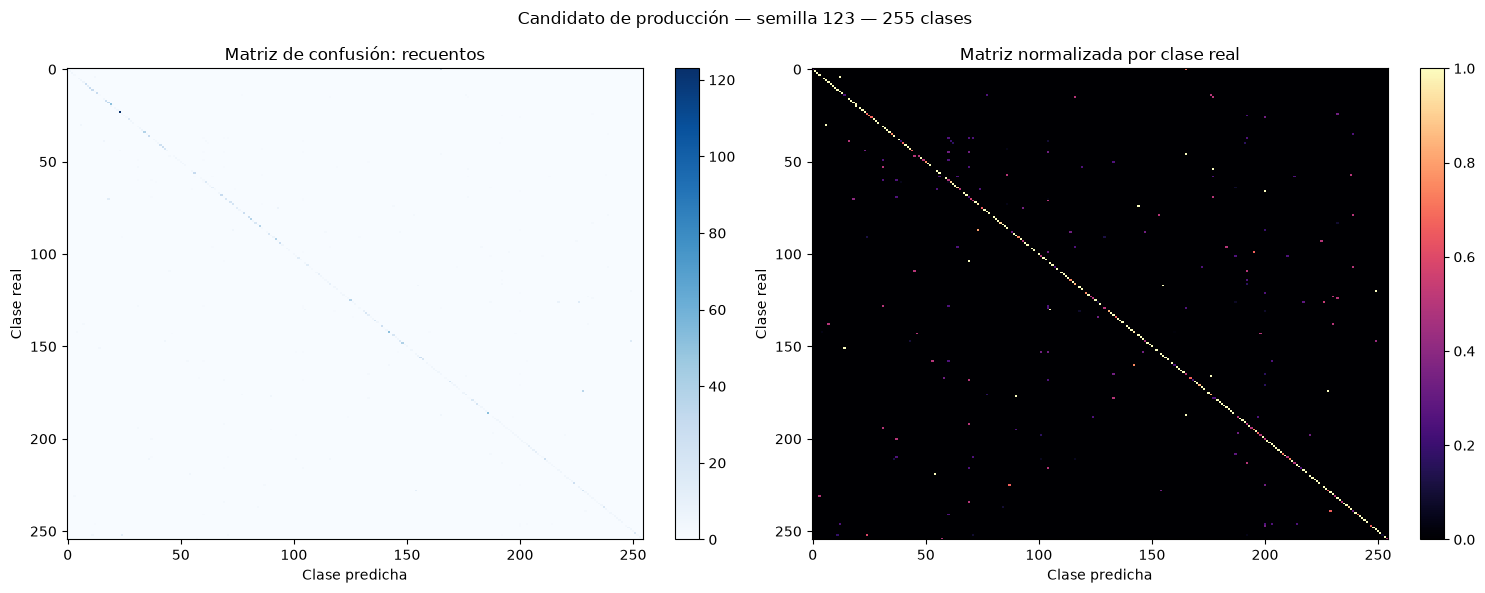


[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/production/final_confusion_pairs.csv | dimensiones: (165, 6)


,true_class_index,true_label,predicted_class_index,predicted_label,count,fraction_of_true_class
0,174,Polylithionite,228,Trilithionite,36,1.000000
1,0,Actinolite,165,Pargasite,27,0.710526
2,147,Monazite-(Ce),249,Wolfeite,16,0.432432
3,126,Leucophanite,226,Tremolite,15,0.535714
4,70,Diopside,18,Augite,14,0.400000
5,252,Xenotime-(Y),24,Bastnasite-(Ce),13,0.590909
6,228,Trilithionite,154,Muscovite,12,0.333333
7,126,Leucophanite,217,Talc,8,0.285714
8,75,Elbaite,93,Foitite,7,0.350000
9,39,Carrollite,16,Arsenopyrite,5,0.500000



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/production/final_30_hardest_classes.csv | dimensiones: (30, 6)


,class_index,label,precision,recall,f1-score,support
174,174,Polylithionite,0.0,0.0,0.0,36.0
87,87,Fluor-uvite,0.0,0.0,0.0,5.0
20,20,Axinite-(Mn),0.0,0.0,0.0,4.0
30,30,Biphosphammite,0.0,0.0,0.0,4.0
37,37,Calaverite,0.0,0.0,0.0,4.0
53,53,Cobaltite,0.0,0.0,0.0,4.0
58,58,Coronadite,0.0,0.0,0.0,4.0
79,79,Eosphorite,0.0,0.0,0.0,4.0
96,96,Gersdorffite,0.0,0.0,0.0,4.0
109,109,Hematite,0.0,0.0,0.0,4.0


,class_index,label,precision,recall,f1-score,support
174,174,Polylithionite,0.0,0.0,0.0,36.0
87,87,Fluor-uvite,0.0,0.0,0.0,5.0
20,20,Axinite-(Mn),0.0,0.0,0.0,4.0
30,30,Biphosphammite,0.0,0.0,0.0,4.0
37,37,Calaverite,0.0,0.0,0.0,4.0
53,53,Cobaltite,0.0,0.0,0.0,4.0
58,58,Coronadite,0.0,0.0,0.0,4.0
79,79,Eosphorite,0.0,0.0,0.0,4.0
96,96,Gersdorffite,0.0,0.0,0.0,4.0
109,109,Hematite,0.0,0.0,0.0,4.0


,true_class_index,true_label,predicted_class_index,predicted_label,count,fraction_of_true_class
0,174,Polylithionite,228,Trilithionite,36,1.000000
1,0,Actinolite,165,Pargasite,27,0.710526
2,147,Monazite-(Ce),249,Wolfeite,16,0.432432
3,126,Leucophanite,226,Tremolite,15,0.535714
4,70,Diopside,18,Augite,14,0.400000
5,252,Xenotime-(Y),24,Bastnasite-(Ce),13,0.590909
6,228,Trilithionite,154,Muscovite,12,0.333333
7,126,Leucophanite,217,Talc,8,0.285714
8,75,Elbaite,93,Foitite,7,0.350000
9,39,Carrollite,16,Arsenopyrite,5,0.500000



[SOLO PANTALLA] raman_all_7_zips_mixed_fixed_split_5_seeds/results/production/final_calibration_bins.csv | dimensiones: (10, 5)


,bin_lower,bin_upper,n_spectra,mean_confidence,observed_accuracy
0,0.0,0.1,128,0.070463,0.148438
1,0.1,0.2,109,0.145375,0.311927
2,0.2,0.3,94,0.248678,0.500000
3,0.3,0.4,73,0.351755,0.657534
4,0.4,0.5,60,0.455799,0.666667
5,0.5,0.6,76,0.557173,0.671053
6,0.6,0.7,81,0.650941,0.777778
7,0.7,0.8,111,0.756157,0.900901
8,0.8,0.9,235,0.855791,0.940426
9,0.9,1.0,1521,0.977027,0.963840


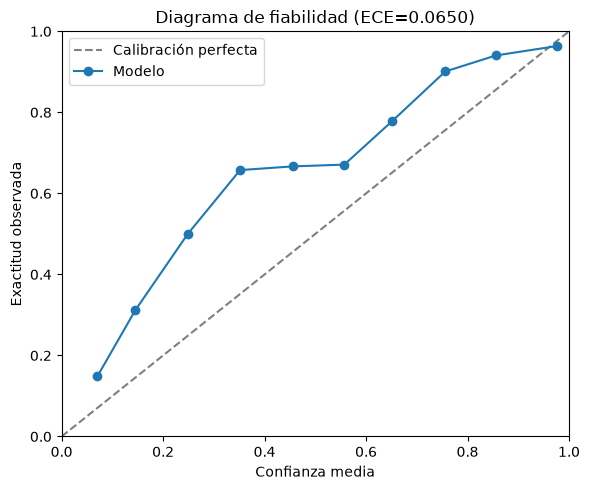

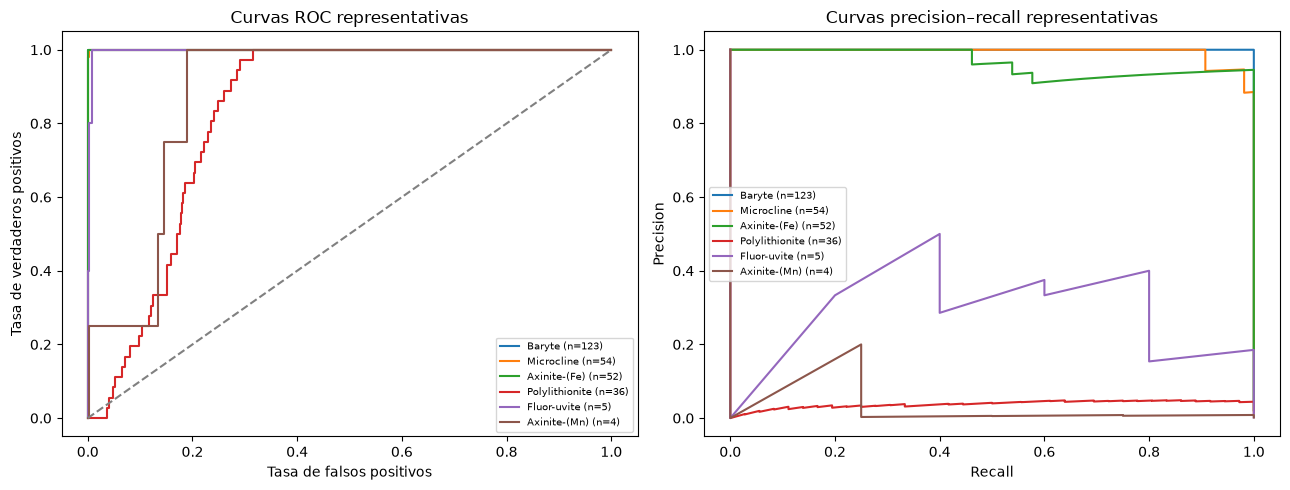

[SOLO PANTALLA] final_test_metrics.json:
{
  "selected_seed": 123,
  "cross_entropy": 0.8457703590393066,
  "top_1_accuracy": 0.8396302250803859,
  "top_3_accuracy": 0.9260450160771704,
  "top_5_accuracy": 0.9364951768488746,
  "macro_precision": 0.747158227906527,
  "macro_recall": 0.7511777933140162,
  "macro_f1": 0.7226750723942345,
  "weighted_precision": 0.8670467662778786,
  "weighted_recall": 0.8396302250803859,
  "weighted_f1": 0.8314506619917973,
  "balanced_accuracy": 0.7511777933140162,
  "matthews_correlation_coefficient": 0.8384527592572353,
  "macro_auroc_ovr": 0.9902451964213965,
  "weighted_auroc_ovr": 0.9917606811794623,
  "macro_auprc_ovr": 0.8088836280022681,
  "weighted_auprc_ovr": 0.8884276803677437,
  "multiclass_brier_score": 0.23797281086444855,
  "expected_calibration_error": 0.0649822574360386,
  "ovr_evaluable_classes": 255
}
✓ Diagnóstico final guardado para el candidato seleccionado por validación: semilla 123


In [17]:
# Se reproduce la regla de selección basada únicamente en validación.
diagnostic_winner = (
    all_histories[np.isfinite(all_histories["val_loss"])]
    .sort_values(["val_loss", "epoch", "seed"], ascending=[True, True, True])
    .iloc[0]
)
diagnostic_seed = int(diagnostic_winner["seed"])
final_probabilities = seed_probabilities[diagnostic_seed]
final_predictions = final_probabilities.argmax(axis=1)
final_metrics = calculate_metrics(y_test, final_probabilities)

PRODUCTION_DIR = RESULTS_DIR / "production"

# Predicciones individuales para trazabilidad y futuros análisis de errores.
available_metadata = [
    c for c in ["spectrum_id", "filepath", "source_id", "label", "dataset_subset"]
    if c in split_manifest.columns
]
final_prediction_table = split_manifest.iloc[test_idx][available_metadata].reset_index(drop=True).copy()
final_prediction_table["true_class_index"] = y_test
final_prediction_table["predicted_class_index"] = final_predictions
final_prediction_table["predicted_label"] = class_names[final_predictions]
final_prediction_table["correct"] = final_predictions == y_test
final_prediction_table["confidence"] = final_probabilities.max(axis=1)
final_prediction_table["true_class_probability"] = final_probabilities[np.arange(len(y_test)), y_test]
final_prediction_table.to_csv(PRODUCTION_DIR / "final_test_predictions.csv", index=False)

# Informe completo por clase, incluyendo explícitamente las clases sin soporte en test.
report = classification_report(
    y_test, final_predictions, labels=np.arange(n_classes), target_names=class_names,
    output_dict=True, zero_division=0,
)
per_class_report = pd.DataFrame(report).T.iloc[:n_classes].reset_index(names="label")
per_class_report.insert(0, "class_index", np.arange(n_classes))
per_class_report.to_csv(PRODUCTION_DIR / "final_per_class_metrics.csv", index=False)

# Matrices de confusión absoluta y normalizada por clase real.
cm_counts = confusion_matrix(y_test, final_predictions, labels=np.arange(n_classes))
row_totals = cm_counts.sum(axis=1, keepdims=True)
cm_normalized = np.divide(
    cm_counts, row_totals, out=np.zeros_like(cm_counts, dtype=float), where=row_totals != 0
)
pd.DataFrame(cm_counts, index=class_names, columns=class_names).to_csv(
    PRODUCTION_DIR / "final_confusion_matrix_counts.csv"
)
pd.DataFrame(cm_normalized, index=class_names, columns=class_names).to_csv(
    PRODUCTION_DIR / "final_confusion_matrix_normalized.csv"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
im0 = axes[0].imshow(cm_counts, aspect="auto", interpolation="nearest", cmap="Blues")
axes[0].set(title="Matriz de confusión: recuentos", xlabel="Clase predicha", ylabel="Clase real")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(cm_normalized, aspect="auto", interpolation="nearest", cmap="magma", vmin=0, vmax=1)
axes[1].set(title="Matriz normalizada por clase real", xlabel="Clase predicha", ylabel="Clase real")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.suptitle(f"Candidato de producción — semilla {diagnostic_seed} — {n_classes} clases")
fig.tight_layout()
plt.show()

# Confusiones fuera de la diagonal, ordenadas por frecuencia absoluta.
confusion_rows = []
for true_index, predicted_index in np.argwhere(cm_counts > 0):
    if true_index != predicted_index:
        confusion_rows.append({
            "true_class_index": int(true_index),
            "true_label": class_names[true_index],
            "predicted_class_index": int(predicted_index),
            "predicted_label": class_names[predicted_index],
            "count": int(cm_counts[true_index, predicted_index]),
            "fraction_of_true_class": float(cm_normalized[true_index, predicted_index]),
        })
top_confusions = pd.DataFrame(confusion_rows)
if not top_confusions.empty:
    top_confusions = top_confusions.sort_values(
        ["count", "fraction_of_true_class"], ascending=False
    ).reset_index(drop=True)
top_confusions.to_csv(PRODUCTION_DIR / "final_confusion_pairs.csv", index=False)

evaluable_classes = per_class_report[per_class_report["support"] > 0].copy()
hardest_classes = evaluable_classes.sort_values(
    ["recall", "f1-score", "support"], ascending=[True, True, False]
).head(30)
hardest_classes.to_csv(PRODUCTION_DIR / "final_30_hardest_classes.csv", index=False)
display(hardest_classes.head(15))
display(top_confusions.head(20) if not top_confusions.empty else pd.DataFrame())

# Diagrama de fiabilidad para la confianza de la clase elegida.
confidence = final_probabilities.max(axis=1)
correctness = (final_predictions == y_test).astype(float)
bin_edges = np.linspace(0.0, 1.0, 11)
bin_ids = np.clip(np.digitize(confidence, bin_edges[1:-1], right=True), 0, 9)
calibration_rows = []
for bin_index in range(10):
    mask = bin_ids == bin_index
    calibration_rows.append({
        "bin_lower": float(bin_edges[bin_index]),
        "bin_upper": float(bin_edges[bin_index + 1]),
        "n_spectra": int(mask.sum()),
        "mean_confidence": float(confidence[mask].mean()) if mask.any() else np.nan,
        "observed_accuracy": float(correctness[mask].mean()) if mask.any() else np.nan,
    })
calibration_table = pd.DataFrame(calibration_rows)
calibration_table.to_csv(PRODUCTION_DIR / "final_calibration_bins.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 5))
valid_bins = calibration_table[calibration_table["n_spectra"] > 0]
ax.plot([0, 1], [0, 1], "--", color="gray", label="Calibración perfecta")
ax.plot(valid_bins["mean_confidence"], valid_bins["observed_accuracy"], "o-", label="Modelo")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Confianza media", ylabel="Exactitud observada",
       title=f"Diagrama de fiabilidad (ECE={final_metrics['expected_calibration_error']:.4f})")
ax.legend()
fig.tight_layout()
plt.show()

# Curvas de un subconjunto legible: tres clases con mayor soporte y tres difíciles.
from sklearn.metrics import precision_recall_curve, roc_curve
representative_indices = []
support_order = evaluable_classes.sort_values("support", ascending=False)["class_index"].astype(int).tolist()
hard_order = hardest_classes["class_index"].astype(int).tolist()
for class_index in support_order[:3] + hard_order:
    binary_truth = (y_test == class_index).astype(int)
    if binary_truth.min() != binary_truth.max() and class_index not in representative_indices:
        representative_indices.append(class_index)
    if len(representative_indices) == 6:
        break

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for class_index in representative_indices:
    binary_truth = (y_test == class_index).astype(int)
    fpr, tpr, _ = roc_curve(binary_truth, final_probabilities[:, class_index])
    precision_curve, recall_curve, _ = precision_recall_curve(binary_truth, final_probabilities[:, class_index])
    label = f"{class_names[class_index]} (n={int(binary_truth.sum())})"
    axes[0].plot(fpr, tpr, label=label)
    axes[1].plot(recall_curve, precision_curve, label=label)
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos", title="Curvas ROC representativas")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Curvas precision–recall representativas")
for ax in axes:
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

(PRODUCTION_DIR / "final_test_metrics.json").write_text(
    json.dumps({"selected_seed": diagnostic_seed, **final_metrics}, indent=2), encoding="utf-8"
)
print(f"✓ Diagnóstico final guardado para el candidato seleccionado por validación: semilla {diagnostic_seed}")


## 17. Exportación del candidato para producción seleccionado mediante validación

Como cierre práctico, se exporta un único checkpoint de los cinco entrenamientos. La elección se realiza exclusivamente con la menor pérdida de validación alcanzada por cada semilla; las métricas del test no intervienen. Esta regla evita convertir el test en un segundo conjunto de validación.

El paquete incluye el modelo Keras, el orden exacto de las etiquetas, la rejilla Raman y un contrato de preprocesamiento. En inferencia, un espectro nuevo debe cubrir el intervalo guardado, interpolarse sobre esa rejilla y normalizarse exactamente igual que durante el experimento. Las probabilidades de salida corresponden, en el mismo orden, a `class_labels.csv`.

Este archivo es un **candidato de despliegue**, no una garantía de validez clínica, industrial o universal. Antes de un uso real debe validarse con espectros externos representativos del instrumento y del contexto de aplicación, vigilar entradas fuera de distribución y conservar una revisión experta.

El paquete final incorpora también todos los diagnósticos del test generados en la sección anterior. Estos resultados documentan el modelo ya seleccionado; no participan en su elección.


In [18]:
# Se selecciona y exporta el candidato para producción utilizando exclusivamente validación.
required_history_columns = {"seed", "epoch", "val_loss"}
missing_history_columns = required_history_columns - set(all_histories.columns)
if missing_history_columns:
    raise RuntimeError(f"Faltan columnas del historial necesarias para seleccionar el modelo de producción: {sorted(missing_history_columns)}")

finite_validation = all_histories[np.isfinite(all_histories["val_loss"])].copy()
if finite_validation.empty:
    raise RuntimeError("No existe una pérdida de validación finita; no se puede seleccionar el modelo para producción.")

# Stable tie-breaks: lower val_loss, then earlier epoch, then lower seed.
winner_row = finite_validation.sort_values(
    ["val_loss", "epoch", "seed"], ascending=[True, True, True]
).iloc[0]
production_seed = int(winner_row["seed"])
production_epoch = int(winner_row["epoch"])
production_val_loss = float(winner_row["val_loss"])
production_val_accuracy = (
    float(winner_row["val_accuracy"])
    if "val_accuracy" in winner_row.index and pd.notna(winner_row["val_accuracy"])
    else None
)

production_model = seed_models[production_seed]
smoke_prob = production_model.predict(X_val[:1], verbose=0)
assert smoke_prob.shape == (1, n_classes) and np.isfinite(smoke_prob).all()
selection_manifest = {
    "selected_seed": production_seed, "selected_best_epoch": production_epoch,
    "selected_validation_loss": production_val_loss, "selected_validation_accuracy": production_val_accuracy,
    "n_classes": int(n_classes), "test_metrics_used_for_selection": False,
    "final_test_metrics_for_reporting_only": final_metrics,
}
display(pd.DataFrame([selection_manifest]).T.rename(columns={0: "value"}))
print(f"✓ Candidato seleccionado en memoria: semilla {production_seed}, época {production_epoch}")
print("No se guardaron modelos, tablas, figuras ni paquetes ZIP.")


E0000 00:00:1786595106.507838  647126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,value
selected_seed,123
selected_best_epoch,7
selected_validation_loss,0.852326
selected_validation_accuracy,0.841556
n_classes,255
test_metrics_used_for_selection,False
final_test_metrics_for_reporting_only,"{'cross_entropy': 0.8457703590393066, 'top_1_a..."


✓ Candidato seleccionado en memoria: semilla 123, época 7
No se guardaron modelos, tablas, figuras ni paquetes ZIP.
